# Mentoring 2 - Fraud Analytics
---
Mohammad Rifqi Zein \
Mentoring Session - Job Preparation Program - Pacmann AI

In [2]:
# Load package
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## 1. Case Description
---

- You are a data scientist in the mobile money transactions company.
- Your company might suffer loss because fraudulent transactions are being processed, leading to financial instability.
- To minimize the loss and increase profitability, your goal is to detect fraudulent claims early in the process and reduce the impact of false claims on the company's revenue.
- As a data scientist, you want to create a rule-based system to detect fraud. By defining specific rules and thresholds, you can identify suspicious cases that deviate from normal patterns, flagging them for further investigation and helping to prevent fraudulent cases from being approved.
- The dataset: [[download here]](https://drive.google.com/file/d/1w48ETL2rltnpHl0TPxRuYbigasa79tPt/view)
- Paper: [https://www.msc-les.org/proceedings/emss/2016/EMSS2016_249.pdf](https://www.msc-les.org/proceedings/emss/2016/EMSS2016_249.pdf)

## 2. Dataset Description
---

|Column|Description|
|:--|:--|
|`step`|Represents a unit of time in the real world, with 1 step equating to 1 hour. The total simulation spans 744 steps, equivalent to 30 days.|
|`type`|Transaction types include CASH-IN, CASH-OUT, DEBIT, PAYMENT, and TRANSFER.|
|`amount`|The transaction amount in the local currency.|
|`nameOrig`|The customer initiating the transaction.|
|`oldbalanceOrg`|The initial balance before the transaction.|
|`newbalanceOrig`|The new balance after the transaction.|
|`nameDest`|The transaction's recipient customer.|
|`oldbalanceDest`|The initial recipient's balance before the transaction. Not applicable for customers identified by 'M' (Merchants).|
|`newbalanceDest`|The new recipient's balance after the transaction. Not applicable for 'M' (Merchants).|
|`isFraud`|Identifies transactions conducted by fraudulent agents aiming to deplete customer accounts through transfers and cash-outs.|
|`isFlaggedFraud`|Flags large-scale, unauthorized transfers between accounts, with any single transaction exceeding 200,000 being considered illegal.|

## 3. The Tools
---

You can use python to do this exercise.

## 4. Your Task
---

## Question 1

Before we can detect fraud, we must clean and prepare our data. This step ensures we have a well-structured dataset for modeling.
- Load the dataset and inspect it for missing values, duplicate records, and inconsistencies.
- Separate the dataset into features (X) and target variable (y), where y represents fraud labels (0 = not fraud, 1 = fraud).
- Split the data into training (80%) and testing (20%) sets using train_test_split().

### **Importing Data**

In [13]:
# read dataset function
def read_data(path):
    """
    Reads a CSV file at the given path, removes any duplicate rows,
    and returns its contents as a pandas DataFrame.

    Parameters
    ----------
    path : str
        The sample data input path (csv format)

    Return
    ------
    df : pd.DataFrame
        The sample data input
    """
    # Read data
    df = pd.read_csv(path)

    # Validate
    print('Data shape:', df.shape)

    return df

In [14]:
# Dataset name / Path
path = 'financial_data_log.csv'

# Read the data
df = read_data(path = path)
df.head()

Data shape: (20000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,615,TRANSFER,56510.50,C956959892,56510.50,0.00,C582952352,0.0,0.00,1,0
1,714,TRANSFER,10000000.00,C131412689,10390763.24,390763.24,C1846567377,0.0,0.00,1,0
2,324,TRANSFER,21580.37,C765450059,21580.37,0.00,C125935569,0.0,0.00,1,0
3,668,CASH_OUT,1576531.53,C2000069930,1576531.53,0.00,C1345448010,0.0,1576531.53,1,0
4,499,TRANSFER,488243.65,C2117568077,488243.65,0.00,C1238599279,0.0,0.00,1,0


Kemudian kita cek missing values dan duplicates.

In [16]:
print("Number of missing values:\n", df.isnull().sum())
print("Number of duplicates:", df.duplicated().sum())

Number of missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
Number of duplicates: 3


Ada 3 data duplikat, jadi sebaiknya kita hapus.

In [18]:
df = df.drop_duplicates()
print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 0


Kemudian kita cek apakah semua nilai numerik bernilai positif (karena tidak mungkin step dan jumlah uang bernilai negatif) dan juga cek apakah semua nilai isFraud dan isFlaggedFraud bernilai 0 dan 1

In [20]:
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
negative_counts = (df[numeric_cols] < 0).sum()

print("Number of negative values:")
print(negative_counts)

print("Unique values of isFraud:", df['isFraud'].unique())
print("Unique values of isFlaggedFraud:", df['isFlaggedFraud'].unique())

Number of negative values:
step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
dtype: int64
Unique values of isFraud: [1 0]
Unique values of isFlaggedFraud: [0 1]


Tidak ada inkonsistensi, jadi kita lanjut ke step berikutnya.

### **Splitting Data**

Kemudian, kita akan melakukan splitting data terlebih dahulu agar tidak terjadi data leaking ketika training dan evaluasi model.

**Split Input & Output**

In [25]:
# function split input and output
def split_input_output(data, target_column):
    """
    Function to split input (x) and output (y)

    Parameters
    ----------
    data : pd.DataFrame
        The sample data input

    target_column : str
        The output column name

    Return
    ------
    X : pd.DataFrame
        input data

    y : pd.DataFrame
        output data
    """
    X = data.drop(columns = target_column)
    y = data[target_column]

    # Validate
    print('X shape:', X.shape)
    print('y shape :', y.shape)

    return X, y

In [26]:
# Split input x and output y
X, y = split_input_output(data = df,
                          target_column = "isFraud")

# Show 5 first rows of input
X.head()

X shape: (19997, 10)
y shape : (19997,)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud
0,615,TRANSFER,56510.50,C956959892,56510.50,0.00,C582952352,0.0,0.00,0
1,714,TRANSFER,10000000.00,C131412689,10390763.24,390763.24,C1846567377,0.0,0.00,0
2,324,TRANSFER,21580.37,C765450059,21580.37,0.00,C125935569,0.0,0.00,0
3,668,CASH_OUT,1576531.53,C2000069930,1576531.53,0.00,C1345448010,0.0,1576531.53,0
4,499,TRANSFER,488243.65,C2117568077,488243.65,0.00,C1238599279,0.0,0.00,0


In [27]:
# Show 5 first rows of output
y.head()

0    1
1    1
2    1
3    1
4    1
Name: isFraud, dtype: int64

In [28]:
# check data dimension
n_samples, n_features = X.shape

# print number samples and features
print(f"Number of samples  : {n_samples}")
print(f"Number of features : {n_features}")

Number of samples  : 19997
Number of features : 10


In [29]:
# check data features name
features_names = X.columns

# print name of features
print(f"name of features : {features_names}")

name of features : Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud'],
      dtype='object')


**Split Train, Valid, and Test Data**

In [31]:
from sklearn.model_selection import train_test_split

def split_train_valid_test(X, y, test_size, stratify, random_state=42):
    """
    Split data into train & test

    Parameters
    ----------
    X : pd.DataFrame
        The input data

    y : pd.Series
        The output data

    test_size : float
        The proportion of number of test data to total data

    stratify : pd.Series
        Reference to stratify the splitting

    random_state : int, default=42
        The random seed, for reproducibility

    Returns
    -------
    X_train : pd.DataFrame
        The input train data

    X_test : pd.DataFrame
        The input test data

    y_train : pd.Series
        The output train data

    y_test : pd.Series
        The output test data
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = test_size,
        stratify = stratify,
        random_state = random_state
    )

    # Validate
    print('X train shape:', X_train.shape)
    print('y train shape:', y_train.shape)
    print('X test shape :', X_test.shape)
    print('y test shape :', y_test.shape)

    return X_train, X_test, y_train, y_test


In [32]:
# Run the code
splitted_data = split_train_valid_test(
    X = X,
    y = y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

X_train, X_test, y_train, y_test = splitted_data

X train shape: (15997, 10)
y train shape: (15997,)
X test shape : (4000, 10)
y test shape : (4000,)


**Create EDA Dataset**

In [34]:
# create EDA dataset
eda_df = pd.concat([X_train, y_train],
                   axis=1)
eda_df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud,isFraud
5599,186,CASH_OUT,117639.37,C1225777611,0.0,0.00,C1232506270,2616241.45,2733880.81,0,0
14173,186,PAYMENT,1296.40,C1938284122,0.0,0.00,M347065391,0.00,0.00,0,0
12445,397,PAYMENT,10179.42,C198881932,0.0,0.00,M1544842379,0.00,0.00,0,0
2737,352,PAYMENT,7376.25,C2016660430,0.0,0.00,M946461682,0.00,0.00,0,0
18674,313,PAYMENT,15378.47,C1047865908,50291.0,34912.53,M1740352773,0.00,0.00,0,0


In [35]:
# Print train set shape after concat
print('eda_df shape:', eda_df.shape)

eda_df shape: (15997, 11)


## Question 2

Understanding the dataset is crucial before applying any model. EDA helps us identify patterns, correlations, and potential outliers that could indicate fraudulent behavior.

- Univariate or Bivariate Analysis : Use 8 histograms and 7 boxplots with categories to check feature distributions.
- Multivariate Analysis: Use 2 scatter plots and correlation matrices to analyze feature relationships.
- Outlier Detection: Identify extreme values that may indicate fraud.
- Provide at least 4 key insights from the EDA that could help in fraud detection.

### Univariate or Bivariate Analysis

Sebelum kita analisis, karena oldbalanceDest dan newbalanceDest tidak applicable untuk Merchant, kita coba pisah dulu data yang nameDest-nya berawalan M dan yang tidak.

In [40]:
eda_df['to_Customer'] = eda_df['nameDest'].str.startswith('C').astype(int)

In [41]:
eda_C = eda_df[~eda_df['nameDest'].str.startswith('M')].copy()
eda_M = eda_df[eda_df['nameDest'].str.startswith('M')].copy()
print(f'to Customer data shape: {eda_C.shape}')
print(f'to Merchant data shape: {eda_M.shape}')

to Customer data shape: (10990, 12)
to Merchant data shape: (5007, 12)


Pertama, kita lihat distribusi variabel numerik terlebih dahulu.

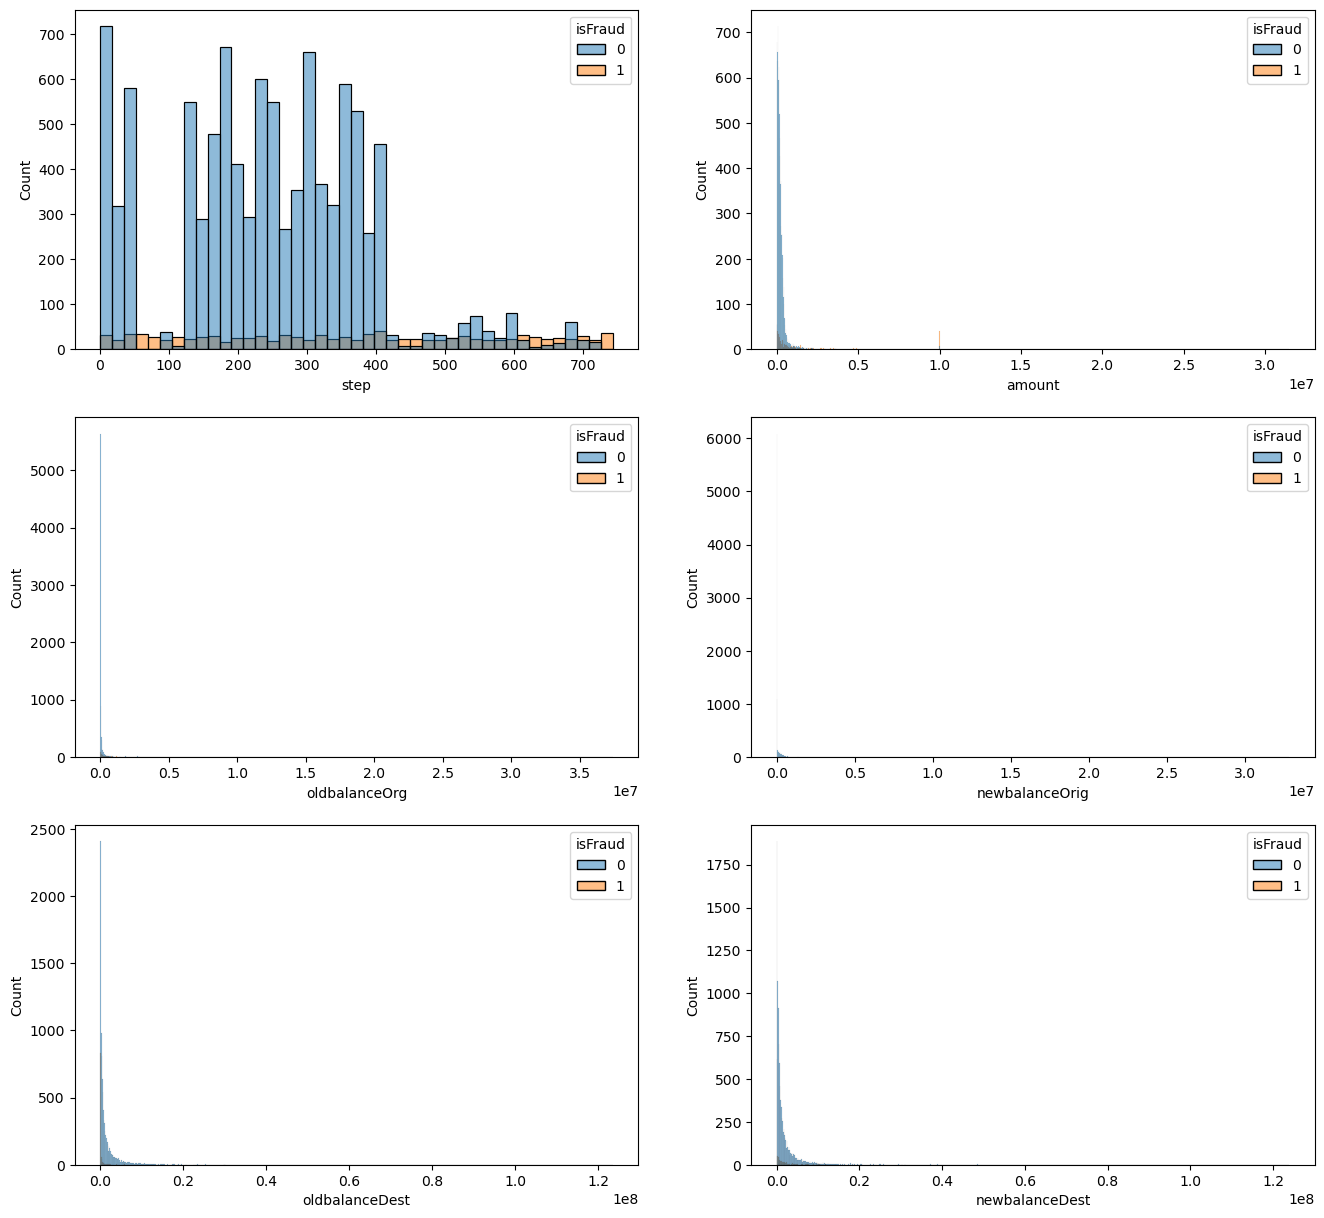

In [43]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
cols_to_hist = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

for i, col in enumerate(cols_to_hist):
    sns.histplot(data=eda_C, x=col, hue='isFraud', ax=axes.flatten()[i])

Selain step, distribusi yang lain tidak terlalu kelihatan. Kita coba transformasi log (dengan log10(1+x) agar nilai 0 dapat terlihat) agar bisa divisualisasi lebih baik.

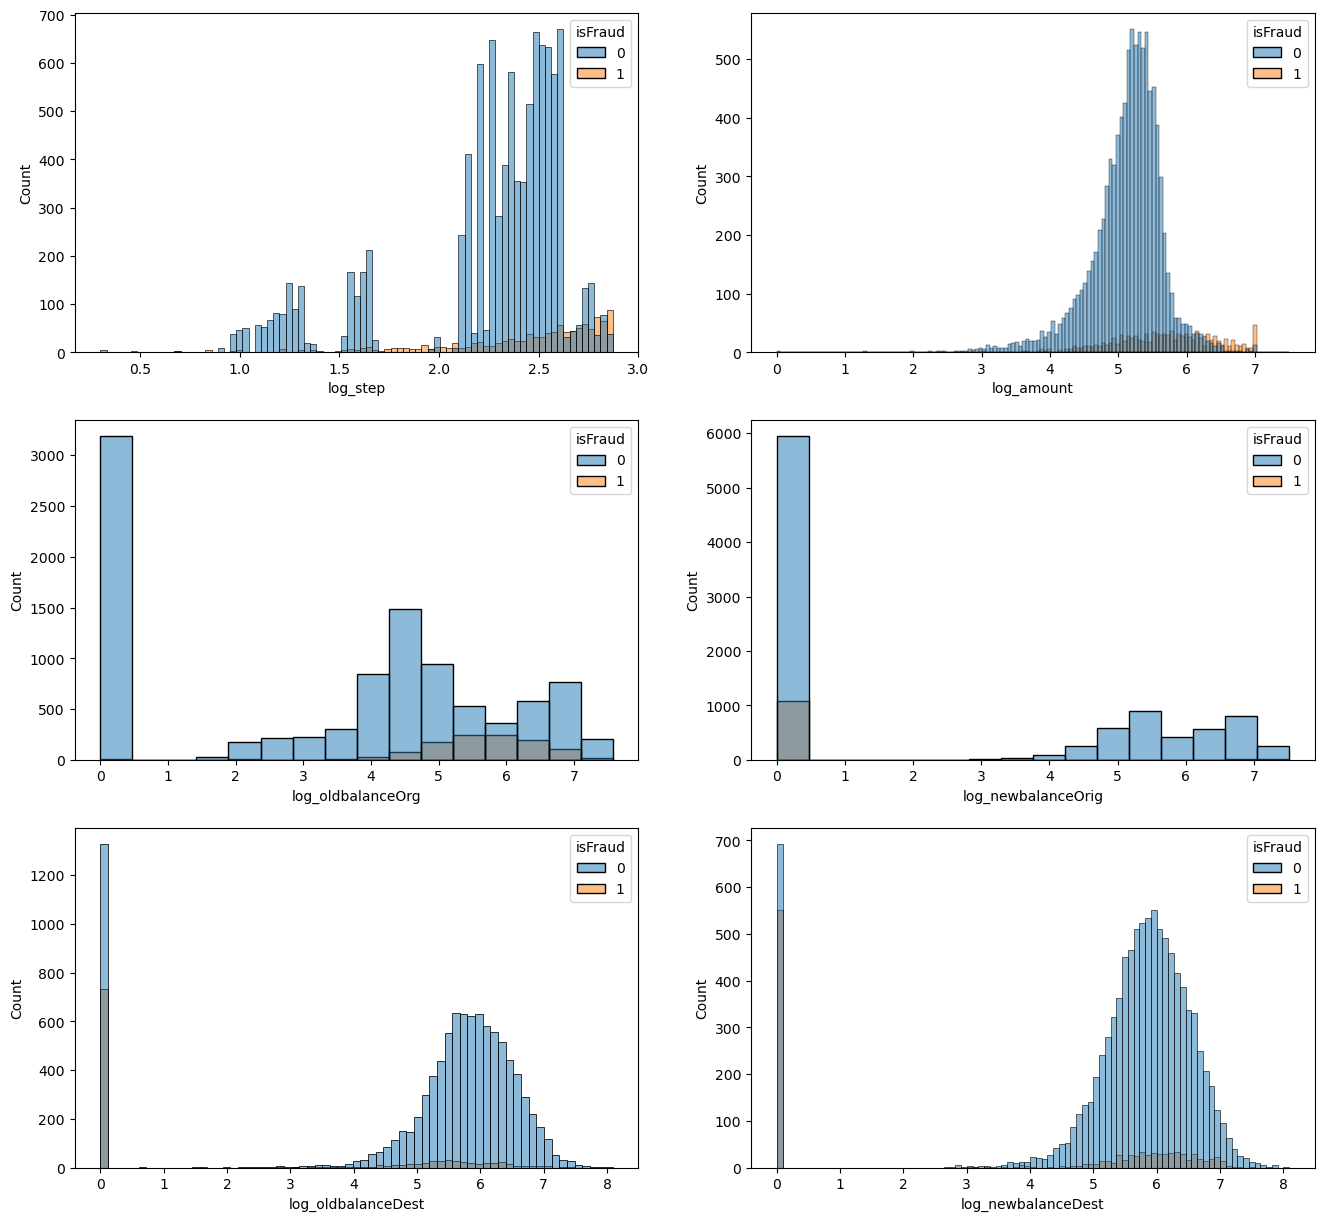

In [45]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
for i, col in enumerate(cols_to_hist):
    eda_C[f'log_{col}'] = np.log10(1+eda_C[col])
    sns.histplot(data=eda_C, x=f'log_{col}', hue='isFraud', ax=axes.flatten()[i])

Lalu, kita coba lihat distribusi data to Merchant.

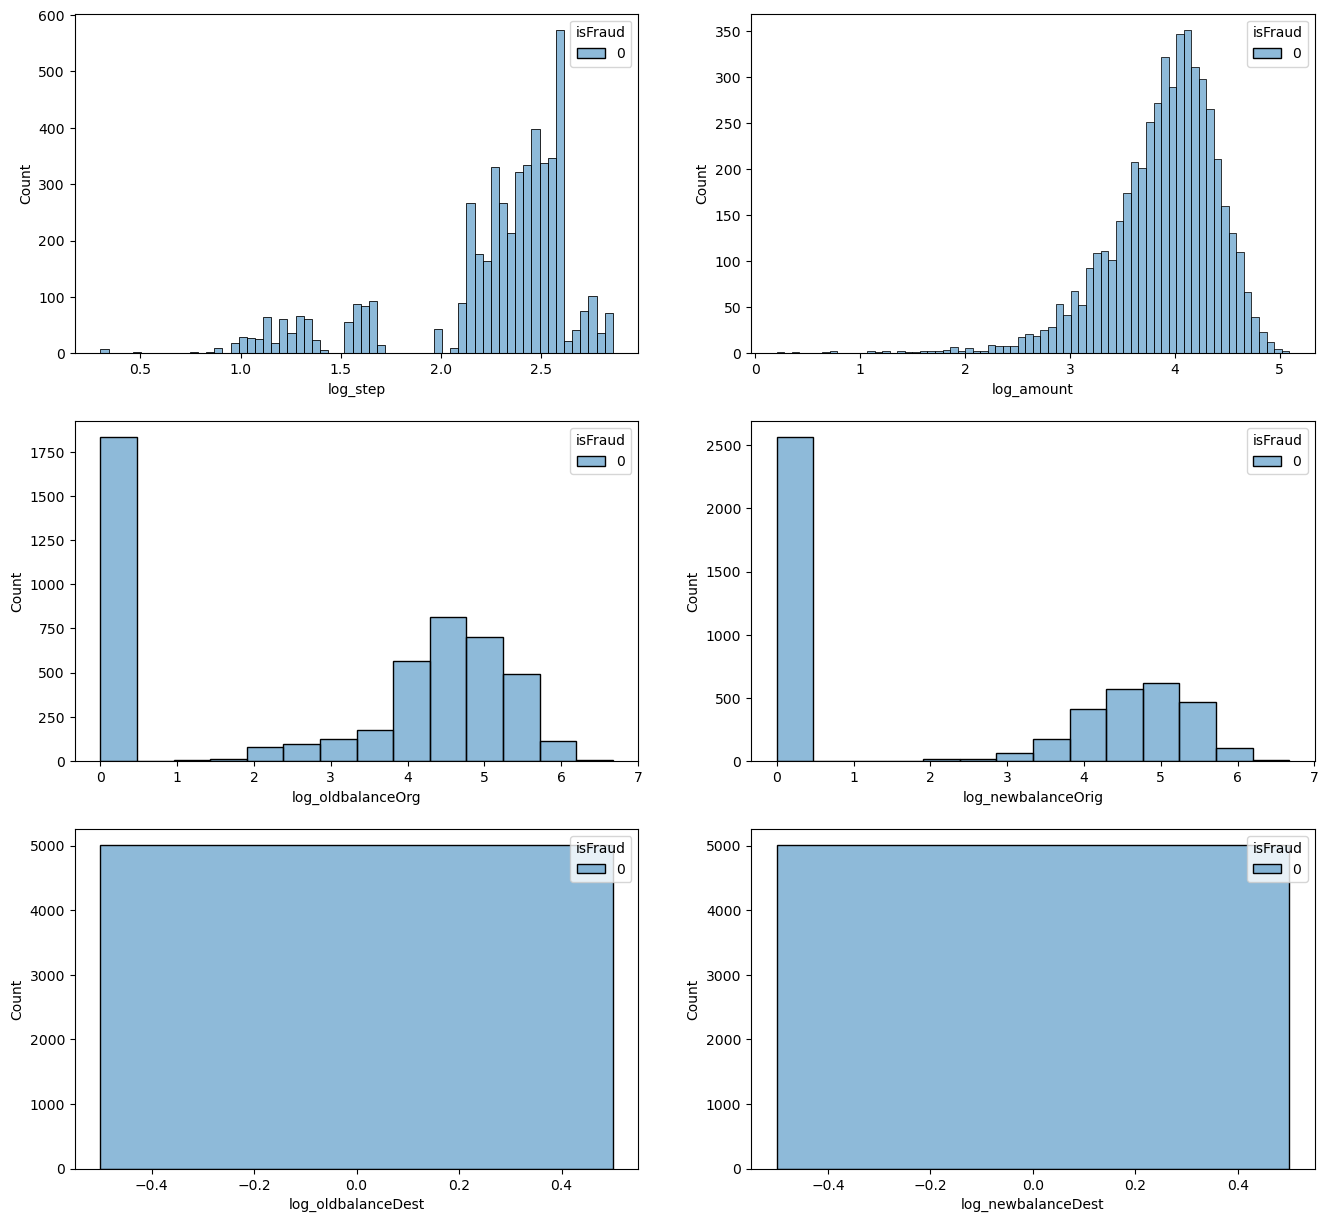

In [47]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
for i, col in enumerate(cols_to_hist):
    eda_M[f'log_{col}'] = np.log10(1+eda_M[col])
    sns.histplot(data=eda_M, x=f'log_{col}', hue='isFraud', ax=axes.flatten()[i])

Ternyata tidak ada kasus Fraud untuk transaksi ke Merchant. Jadi bisa kita abaikan untuk analisis selanjutnya. Kita hanya akan fokus ke data to Customer saja (eda_C) untuk selanjutnya.

Kemudian, kita lihat distribusi `type` dan `isFlaggedFraud`.

<Axes: xlabel='isFlaggedFraud', ylabel='count'>

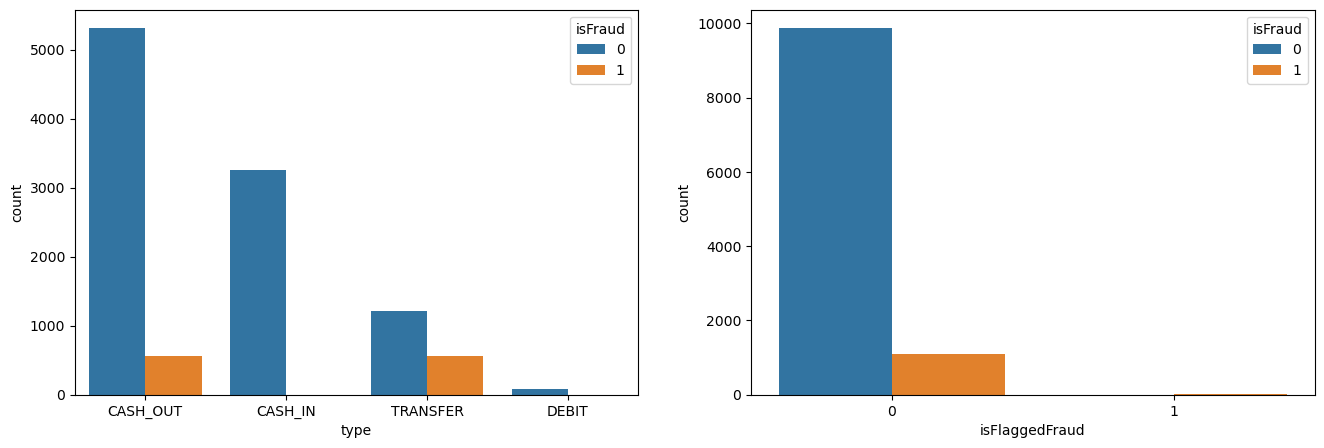

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=eda_C, x='type', hue='isFraud', ax=axes.flatten()[0])
sns.countplot(data=eda_C, x='isFlaggedFraud', hue='isFraud', ax=axes.flatten()[1])

Ternyata type PAYMENT hanya ada di transaksi dengan Merchant saja.

Lalu, kita coba cek dengan crosstab karena CASH_IN, dan DEBIT terlihat tidak ada kasus fraud.

In [53]:
# Membuat tabel silang antara tipe transaksi dan status fraud
tabel_fraud_type = pd.crosstab(eda_C['type'], eda_C['isFraud'])
print(tabel_fraud_type)

isFraud      0    1
type               
CASH_IN   3256    0
CASH_OUT  5311  564
DEBIT       87    0
TRANSFER  1218  554


Ternyata benar, hanya CASH_OUT dan TRANSFER yang memiliki kasus fraud.

Selain itu juga, kita coba data dengan `isFlaggedFraud`==1 untuk melihat apakah `isFlaggedFraud` sudah sesuai definisi (Flags large-scale, unauthorized transfers between accounts, with any single transaction exceeding 200,000 being considered illegal) atau belum.

In [56]:
eda_C[eda_C['isFlaggedFraud'] == 1].describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,isFraud,to_Customer,log_step,log_amount,log_oldbalanceOrg,log_newbalanceOrig,log_oldbalanceDest,log_newbalanceDest
count,15.000000,1.500000e+01,1.500000e+01,1.500000e+01,15.0,15.0,15.0,15.0,15.0,15.000000,15.000000,15.000000,15.000000,15.0,15.0
mean,536.466667,4.947284e+06,8.100640e+06,8.100640e+06,0.0,0.0,1.0,1.0,1.0,2.698457,6.495672,6.672194,6.672194,0.0,0.0
std,188.224739,3.680830e+06,7.121804e+06,7.121804e+06,0.0,0.0,0.0,0.0,0.0,0.183750,0.514619,0.549016,0.549016,0.0,0.0
min,212.000000,3.538742e+05,3.538742e+05,3.538742e+05,0.0,0.0,1.0,1.0,1.0,2.328380,5.548850,5.548850,5.548850,0.0,0.0
25%,406.000000,1.942833e+06,2.856875e+06,2.856875e+06,0.0,0.0,1.0,1.0,1.0,2.609121,6.266683,6.453249,6.453249,0.0,0.0
50%,617.000000,4.892193e+06,4.953893e+06,4.953893e+06,0.0,0.0,1.0,1.0,1.0,2.790988,6.689504,6.694947,6.694947,0.0,0.0
75%,686.500000,8.450648e+06,1.385765e+07,1.385765e+07,0.0,0.0,1.0,1.0,1.0,2.837162,6.922941,7.127724,7.127724,0.0,0.0
max,741.000000,1.000000e+07,1.958504e+07,1.958504e+07,0.0,0.0,1.0,1.0,1.0,2.870404,7.000000,7.291924,7.291924,0.0,0.0


Ternyata benar, semua data bertipe Transfer (kemungkinan ini semua unauthorized transfer) dan melebihi 200,000. Selain itu, semua data dengan isFlaggedFraud == 1 ternyata semuanya menjadi transaksi fraud (isFraud == 1).

Kemudian, kita coba cek distribusi dengan box and whisker diagram.

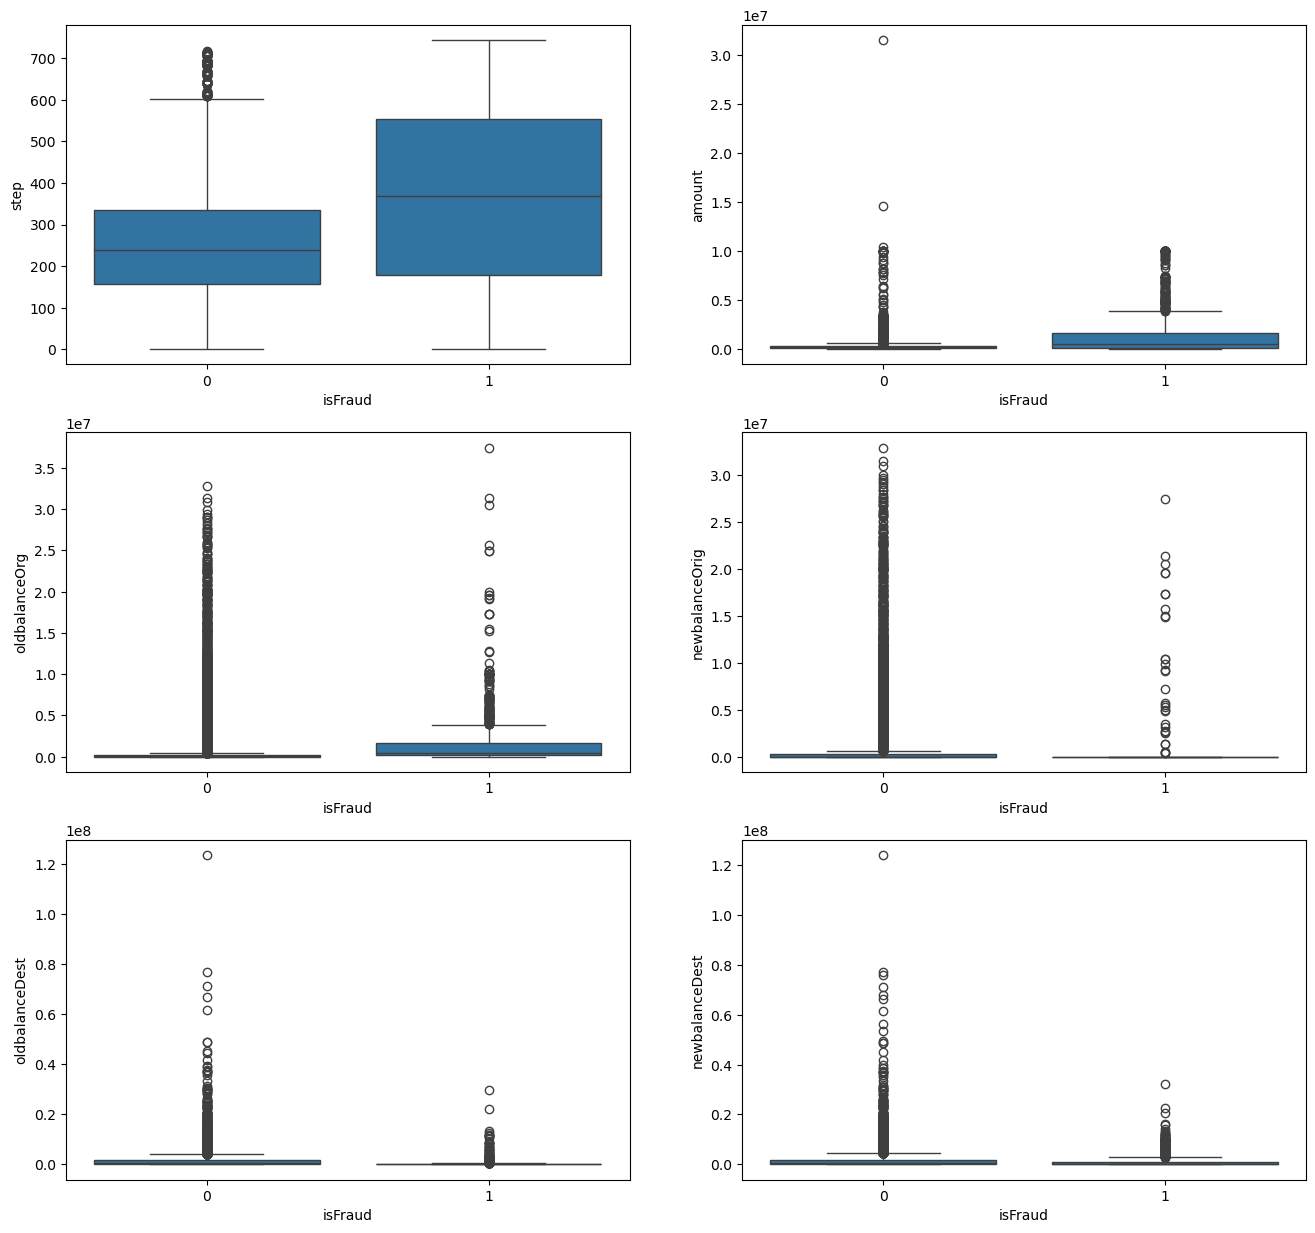

In [59]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
for i, col in enumerate(cols_to_hist):
    sns.boxplot(data=eda_C, x='isFraud', y=col, ax=axes.flatten()[i])

Lagi-lagi selain step, distribusi yang lain tidak terlalu kelihatan. Kita coba transformasi log (dengan log10(1+x) agar nilai 0 dapat terlihat) agar bisa divisualisasi lebih baik.

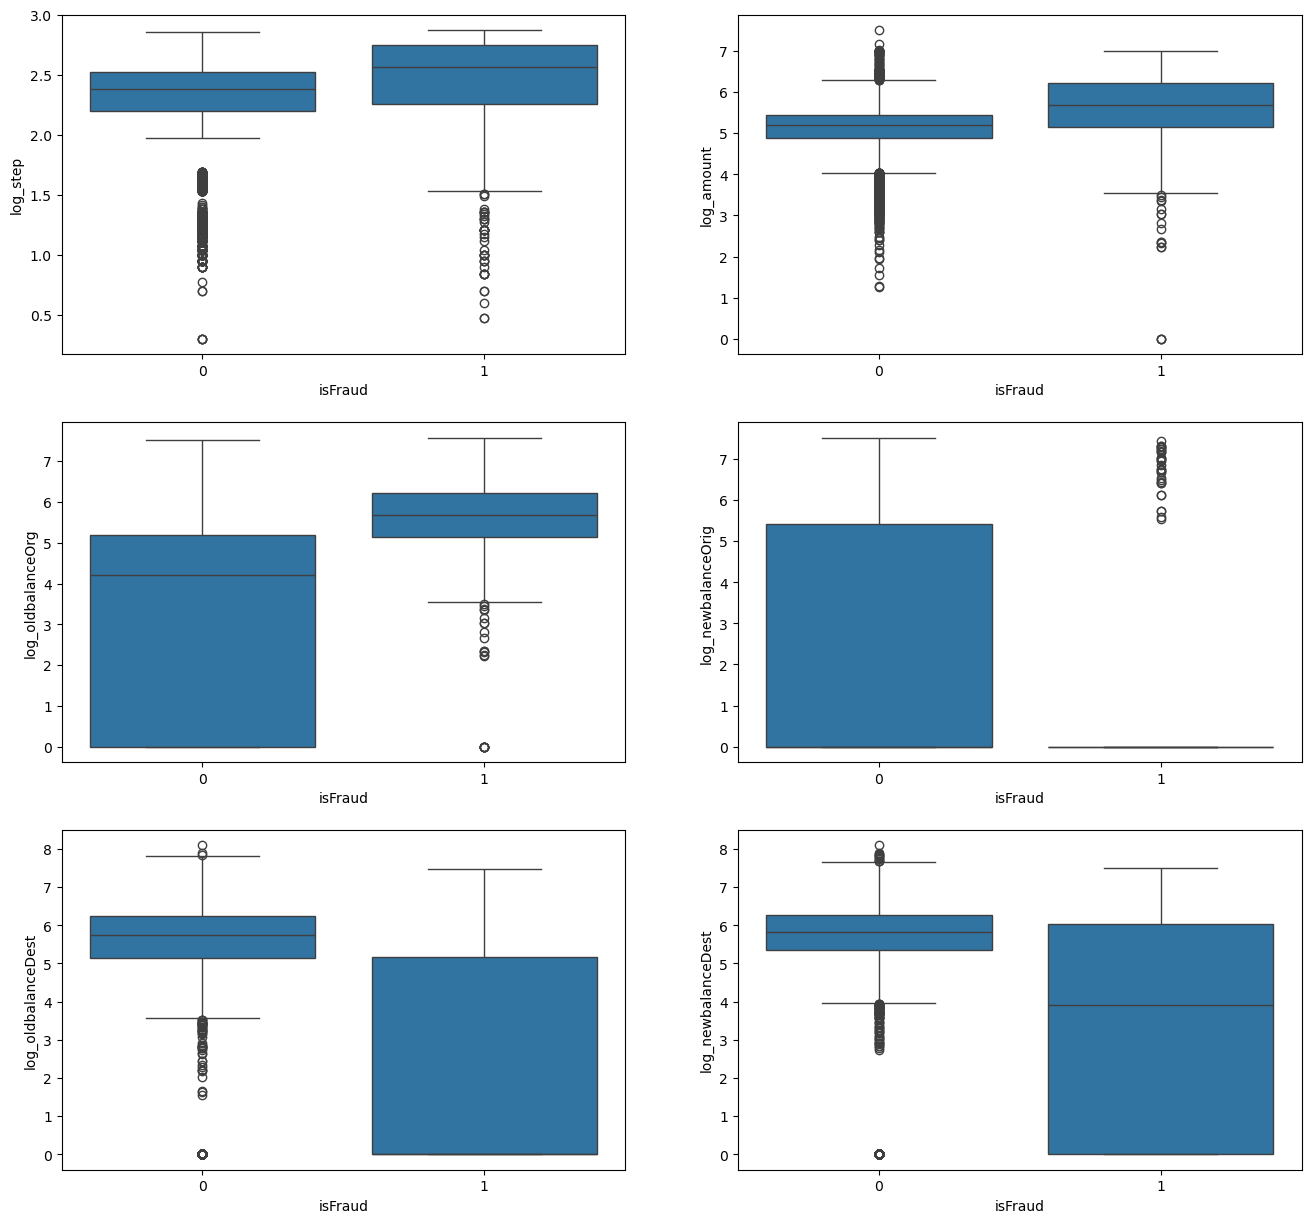

In [61]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
for i, col in enumerate(cols_to_hist):
    sns.boxplot(data=eda_C, x='isFraud', y=f'log_{col}', ax=axes.flatten()[i])

Untuk satu diagram box and whisker yang lain, kita coba lihat distribusi log_amount dari tiap kategori `type`.

<Axes: xlabel='type', ylabel='log_amount'>

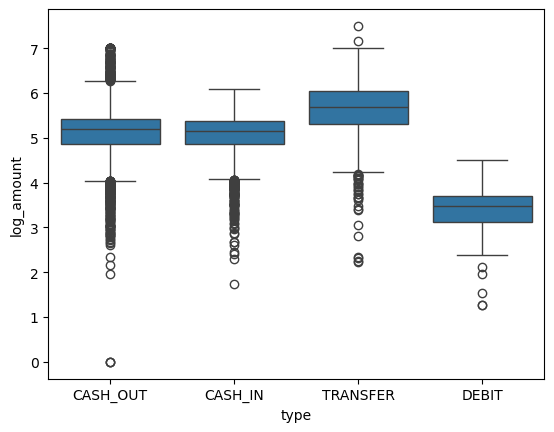

In [63]:
sns.boxplot(data=eda_C, x='type', y='log_amount')

Dari analisis ini semua, dapat dilihat bahwa:
- Dari histplot untuk data transaksi to Merchant (eda_M), dapat dilihat bahwa tidak ada kasus Fraud untuk transaksi ke Merchant. Jadi, untuk selanjutnya, kita hanya akan fokus ke data to Customer saja (eda_C).
- Dari countplot variabel `type` dan analisis tadi, dapat dilihat bahwa kasus fraud hanya terjadi pada transaksi berjenis TRANSFER dan CASH_OUT. Tipe transaksi lain seperti CASH_IN dan DEBIT bersih dari fraud. Selain itu juga, transaksi yang bukan ke Merchant (eda_C) tidak ada yang memiliki type PAYMENT.
- Dari analisis tadi, dapat dilihat bahwa semua data dengan isFlaggedFraud == 1 memiliki tipe transaksi Transfer (kemungkinan ini semua unauthorized transfer), nilai transaksi melebihi 200,000 dan semuanya menjadi transaksi fraud (isFraud == 1).
- Dari histplot variabel `log_amount`, dapat dilihat bahwa median nilai transaksi fraud lebih besar daripada transaksi normal (karena grafik terlihat cenderung lebih ke kanan).
- Dari boxplot variabel `log_newbalanceOrig`, dapat dilihat bahwa hampir semua transaksi fraud memiliki nilai 0, artinya transaksi fraud seringnya akan menguras habis transaksi asal.
- Dari boxplot variabel 'log_amount' terhadap `type`, dapat dilihat bahwa TRANSFER memiliki nilai median paling tinggi, sementara PAYMENT dan DEBIT memiliki nilai median yang lebih rendah dibanding jenis transaksi lainnya.

### Multivariate Analysis

Pertama, kita coba cek apakah nilai amount sudah sesuai dengan selisih balance akun asal dan juga sesuai dengan selisih balance akun tujuan dengan scatterplot.

In [67]:
# Menghitung selisih (nilai mutlak agar selalu positif)
eda_df['diff_Orig'] = np.abs(eda_df['newbalanceOrig'] - eda_df['oldbalanceOrg'])
eda_df['diff_Dest'] = np.abs(eda_df['newbalanceDest'] - eda_df['oldbalanceDest'])

Text(0.5, 1.0, 'diff_Dest vs amount')

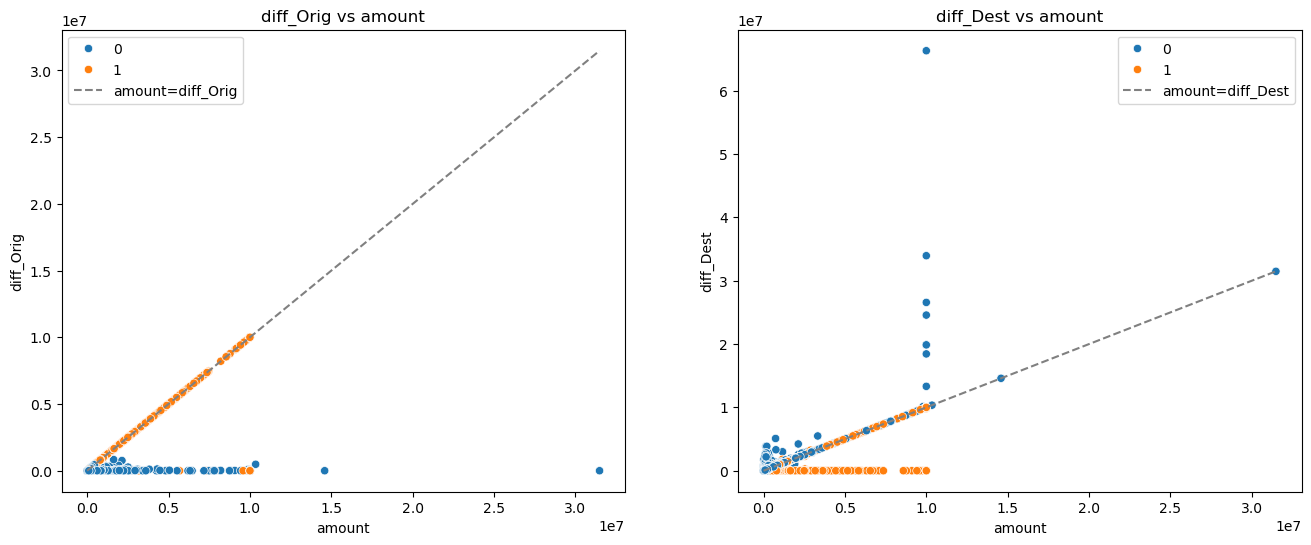

In [68]:
# Menghitung selisih (nilai mutlak agar selalu positif)
eda_C['diff_Orig'] = np.abs(eda_C['newbalanceOrig'] - eda_C['oldbalanceOrg'])
eda_C['diff_Dest'] = np.abs(eda_C['newbalanceDest'] - eda_C['oldbalanceDest'])

# Membuat scatter plot (Amount vs Diff)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Origin
sns.scatterplot(data=eda_C, x='amount', y='diff_Orig', hue='isFraud', ax=axes[0])
axes[0].plot([0, eda_C['amount'].max()], [0, eda_C['amount'].max()], color='gray', linestyle='--', label='amount=diff_Orig') 
axes[0].legend()
axes[0].set_title('diff_Orig vs amount')

# Plot Destination
sns.scatterplot(data=eda_C, x='amount', y='diff_Dest', hue='isFraud', ax=axes[1])
axes[1].plot([0, eda_C['amount'].max()], [0, eda_C['amount'].max()], color='gray', linestyle='--', label='amount=diff_Dest')
axes[1].legend()
axes[1].set_title('diff_Dest vs amount')

Ternyata ada transaksi baik yang normal maupun fraud yang nilai amount tidak sama dengan diff_Orig atau diff_Dest. Kita coba analisis lebih lanjut. \
Pertama, kita coba cek data yang selisih balance akun asalnya jauh berbeda dengan jumlah transaksi (amount).

Text(0.5, 1.0, 'Analysis of Origin Balance Inconsistency')

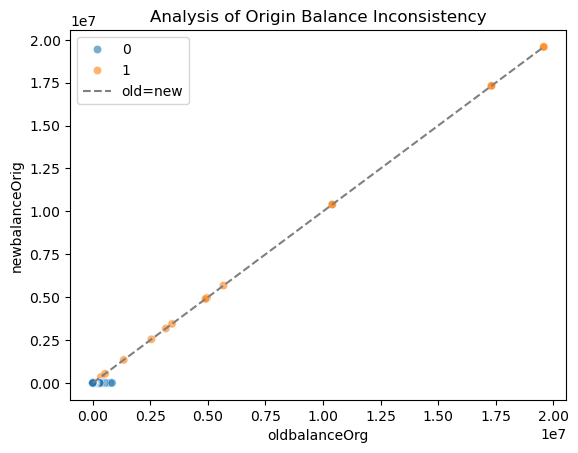

In [70]:
eda_diff_orig = eda_C[np.abs(eda_C['diff_Orig'] - eda_C['amount'])>0.1].copy() # kita ambil yang selisihnya besar saja
sns.scatterplot(data=eda_diff_orig, x='oldbalanceOrg', y='newbalanceOrig', hue='isFraud', alpha=0.6)
plt.plot([0, eda_diff_orig['oldbalanceOrg'].max()], [0, eda_diff_orig['oldbalanceOrg'].max()], color='gray', linestyle='--', label='old=new') 
plt.legend()
plt.title('Analysis of Origin Balance Inconsistency')

Text(0.5, 1.0, 'Analysis of Origin Balance Inconsistency in Normal Cases')

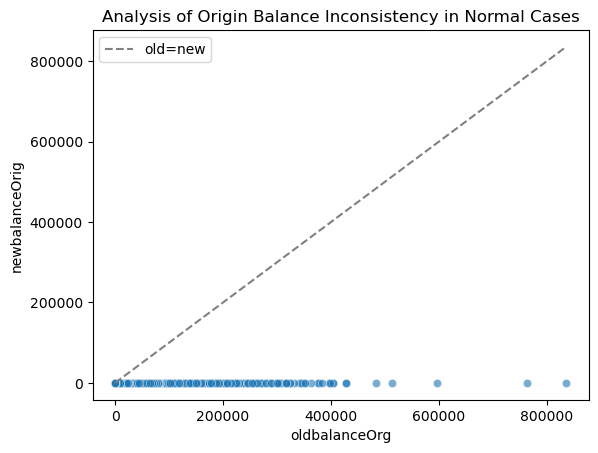

In [71]:
eda_orig_normal = eda_diff_orig[eda_diff_orig['isFraud']==0]
sns.scatterplot(data=eda_orig_normal, x='oldbalanceOrg', y='newbalanceOrig', alpha=0.6)
plt.plot([0, eda_orig_normal['oldbalanceOrg'].max()], [0, eda_orig_normal['oldbalanceOrg'].max()], color='gray', linestyle='--', label='old=new') 
plt.legend()
plt.title('Analysis of Origin Balance Inconsistency in Normal Cases')

Text(0.5, 1.0, 'Analysis of Origin Balance Inconsistency in Fraud Cases')

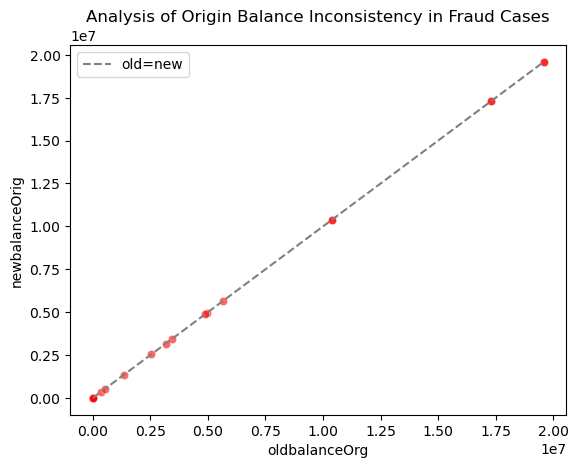

In [72]:
eda_orig_fraud = eda_diff_orig[eda_diff_orig['isFraud']==1]
sns.scatterplot(data=eda_orig_fraud, x='oldbalanceOrg', y='newbalanceOrig', alpha=0.6, color='red')
plt.plot([0, eda_orig_fraud['oldbalanceOrg'].max()], [0, eda_orig_fraud['oldbalanceOrg'].max()], color='gray', linestyle='--', label='old=new') 
plt.legend()
plt.title('Analysis of Origin Balance Inconsistency in Fraud Cases')

In [73]:
eda_orig_fraud[['amount','oldbalanceOrg','newbalanceOrig','diff_Orig']]

,amount,oldbalanceOrg,newbalanceOrig,diff_Orig
1395,3441041.46,3441041.46,3441041.46,0.0
1398,7316255.05,17316255.05,17316255.05,0.0
136,23292.30,0.00,0.00,0.0
1384,4953893.08,4953893.08,4953893.08,0.0
1397,10000000.00,17316255.05,17316255.05,0.0
764,508782.20,0.00,0.00,0.0
1392,2542664.27,2542664.27,2542664.27,0.0
958,95428.32,0.00,0.00,0.0
1391,353874.22,353874.22,353874.22,0.0
1385,1343002.08,1343002.08,1343002.08,0.0


Ternyata semua transaksi fraud yang selisih balance akun asalnya jauh berbeda dengan jumlah transaksi (amount) itu memiliki selisih saldo = 0. \
Artinya, saldo akun asal tidak bertambah atau berkurang. \
Sementara, semua transaksi normal yang selisih balance akun asalnya jauh berbeda dengan jumlah transaksi (amount) itu memiliki newbalanceOrig = 0. \
Lalu, kita coba cek data yang selisih balance akun tujuannya jauh berbeda dengan jumlah transaksi (amount).

Text(0.5, 1.0, 'Analysis of Destination Balance Inconsistency')

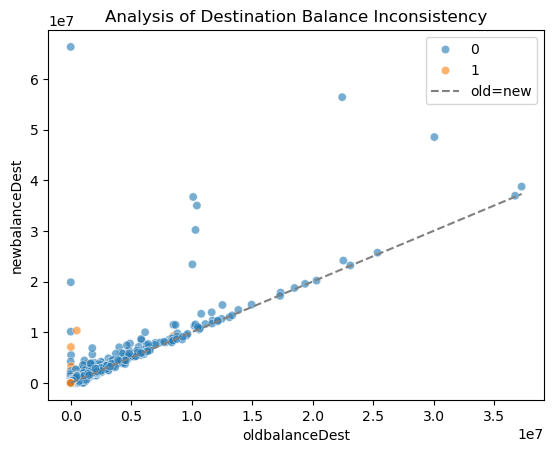

In [75]:
eda_diff_dest = eda_C[np.abs(eda_C['diff_Dest'] - eda_C['amount'])>0.1].copy() # kita ambil yang selisihnya besar saja
sns.scatterplot(data=eda_diff_dest, x='oldbalanceDest', y='newbalanceDest', hue='isFraud', alpha=0.6)
plt.plot([0, eda_diff_dest['oldbalanceDest'].max()], [0, eda_diff_dest['oldbalanceDest'].max()], color='gray', linestyle='--', label='old=new') 
plt.legend()
plt.title('Analysis of Destination Balance Inconsistency')

In [76]:
eda_dest_fraud = eda_diff_dest[eda_diff_dest['isFraud']==1]
eda_dest_fraud[['amount','oldbalanceDest','newbalanceDest','diff_Dest']]

,amount,oldbalanceDest,newbalanceDest,diff_Dest
1127,1064425.70,0.00,0.00,0.00
229,26654.46,0.00,0.00,0.00
1260,235512.20,8490637.21,9272647.09,782009.88
459,438139.79,0.00,0.00,0.00
901,2140888.35,0.00,0.00,0.00
...,...,...,...,...
1050,813133.35,0.00,0.00,0.00
1082,597411.76,0.00,0.00,0.00
1377,834495.09,0.00,0.00,0.00
746,799123.57,0.00,0.00,0.00


In [77]:
eda_dest_fraud['diff_Dest'].value_counts()

diff_Dest
0.00          547
782009.88       1
980959.23       1
140292.51       1
101717.84       1
1789942.62      1
7079766.93      1
127255.69       1
276871.71       1
582265.81       1
3240346.04      1
561182.90       1
10935.00        1
9838091.28      1
267095.19       1
2301330.20      1
1246087.79      1
1803365.60      1
27335.00        1
191529.39       1
75179.00        1
146939.35       1
302550.56       1
2333365.29      1
261290.69       1
233715.19       1
96795.60        1
69861.26        1
1711850.74      1
162310.05       1
Name: count, dtype: int64

Text(0.5, 1.0, 'Analysis of Destination Balance Inconsistency in Normal Cases')

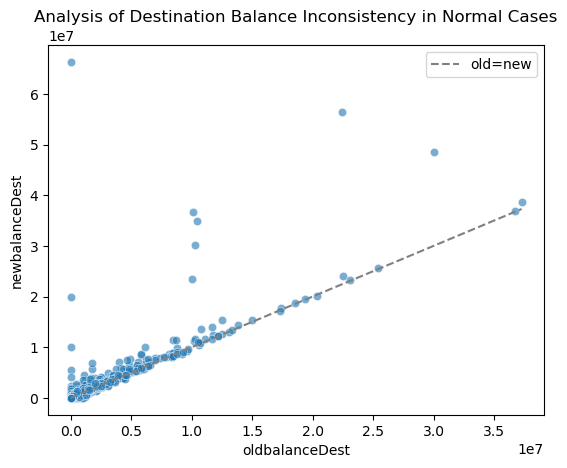

In [78]:
eda_dest_normal = eda_diff_dest[eda_diff_dest['isFraud']==0]
sns.scatterplot(data=eda_dest_normal, x='oldbalanceDest', y='newbalanceDest', alpha=0.6)
plt.plot([0, eda_dest_normal['oldbalanceDest'].max()], [0, eda_dest_normal['oldbalanceDest'].max()], color='gray', linestyle='--', label='old=new') 
plt.legend()
plt.title('Analysis of Destination Balance Inconsistency in Normal Cases')

Text(0.5, 1.0, 'Analysis of Destination Balance Inconsistency in Fraud Cases')

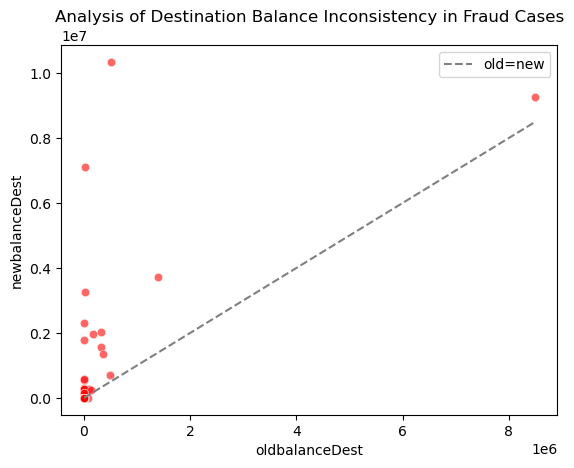

In [79]:
sns.scatterplot(data=eda_dest_fraud, x='oldbalanceDest', y='newbalanceDest', alpha=0.6, color='red')
plt.plot([0, eda_dest_fraud['oldbalanceDest'].max()], [0, eda_dest_fraud['oldbalanceDest'].max()], color='gray', linestyle='--', label='old=new') 
plt.legend()
plt.title('Analysis of Destination Balance Inconsistency in Fraud Cases')

Ternyata sebagian besar transaksi fraud yang selisih balance akun tujuannya jauh berbeda dengan jumlah transaksi (amount) itu memiliki karakteristik berikut:
- Sebagian besar memiliki `oldbalanceDest` == 0
- Sebagian besar memiliki `newbalanceDest` == 0 atau bertambah jauh lebih basar dari sebelumnya.
- Sebagian besar memiliki selisih saldo tujuan == 0 atau sangat besar selisih saldonya.

Sementara itu, untuk transaksi normal yang selisih balance akun tujuannya jauh berbeda dengan jumlah transaksi (amount) itu lebih beragam nilai oldbalanceDest dan newbalanceDest-nya (sebagian besar terjadi ketika saldonya tidak berubah). \

Selanjutnya, kita coba analisis transaksi fraud dan normal menggunakan correlation matrix.

Text(0.5, 1.0, 'Korelasi: Transaksi FRAUD')

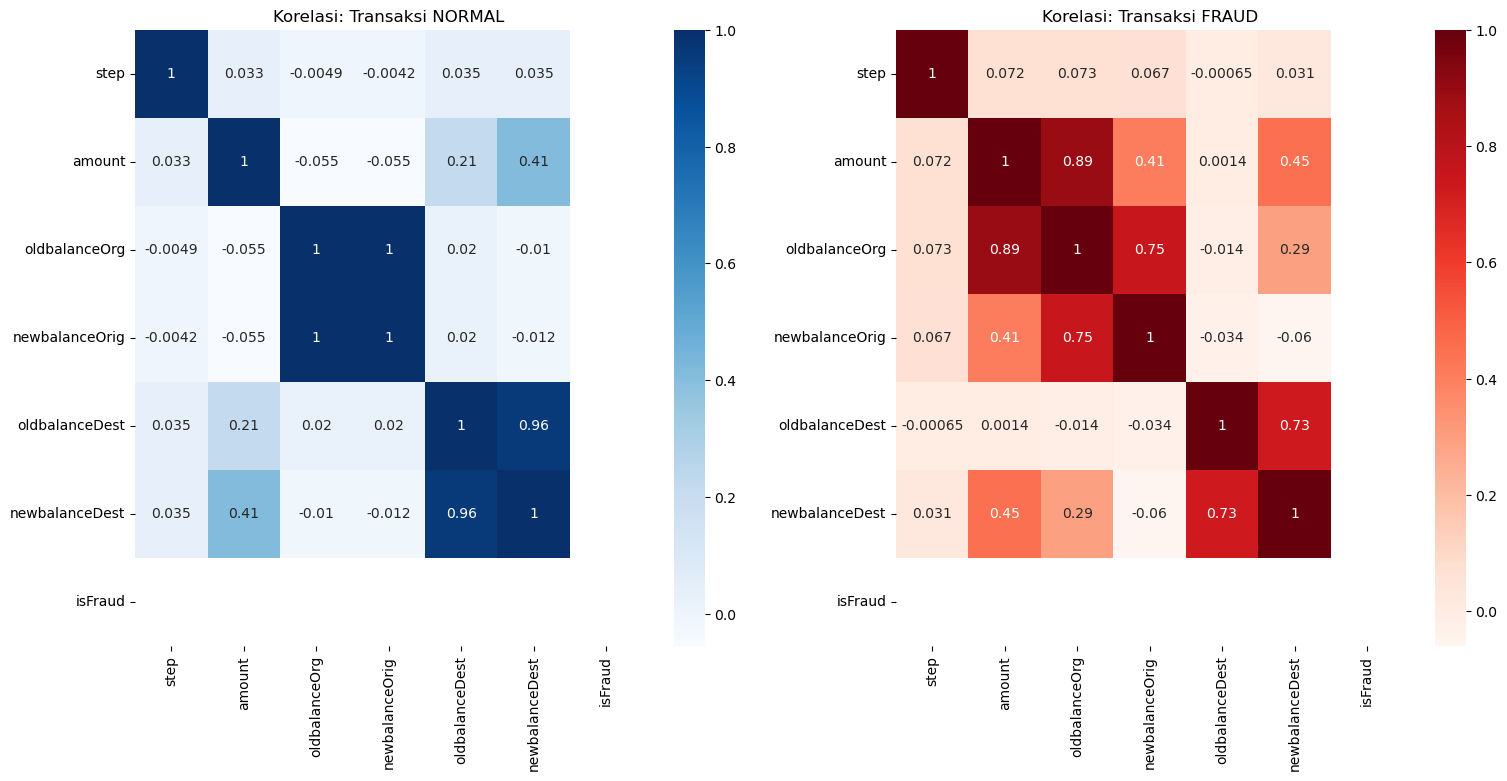

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
corr_df = eda_C[cols_to_hist+['isFraud']]

# Matriks 1: Khusus Transaksi Normal (isFraud == 0)
normal_df = corr_df[corr_df['isFraud'] == 0]
sns.heatmap(normal_df.corr(), annot=True, cmap='Blues', ax=axes[0])
axes[0].set_title('Korelasi: Transaksi NORMAL')

# Matriks 2: Khusus Transaksi Fraud (isFraud == 1)
fraud_df = corr_df[corr_df['isFraud'] == 1]
sns.heatmap(fraud_df.corr(), annot=True, cmap='Reds', ax=axes[1])
axes[1].set_title('Korelasi: Transaksi FRAUD')

Pada Transaksi Normal (Biru): 
- Korelasi antara oldbalanceOrg dan newbalanceOrig adalah positif dan sangat tinggi (1.00).
- Korelasi antara oldbalanceDest dan newbalanceDest juga positif dan sangat tinggi (0.96).
- Korelasi antara amount dan oldbalanceOrg serta korelasi antara amount dan newbalanceOrig nyaris 0 (-0.055). Ini artinya tidak ada korelasi antara nilai transaksi dengan saldo akun asal.

Pada Transaksi Fraud (Merah): 
- Korelasi antara oldbalanceOrg dan newbalanceOrig adalah positif namun lebih kecil dari transaksi normal (0.75)
- Korelasi antara oldbalanceDest dan newbalanceDest juga positif dan lebih kecil dari transaksi normal (0.73)
- Korelasi antara amount dan oldbalanceOrg serta korelasi antara amount dan newbalanceOrig jauh lebih tinggi (0.89 dan 0.41). Ini artinya ada korelasi positif antara nilai transaksi dengan saldo akun asal. Semakin besar transaksi fraud, semakin besar juga saldo akun asal.

### Outlier Detection

Selanjutnya, kita bisa melihat outlier dari box and whisker diagram yang sudah kita buat tadi.

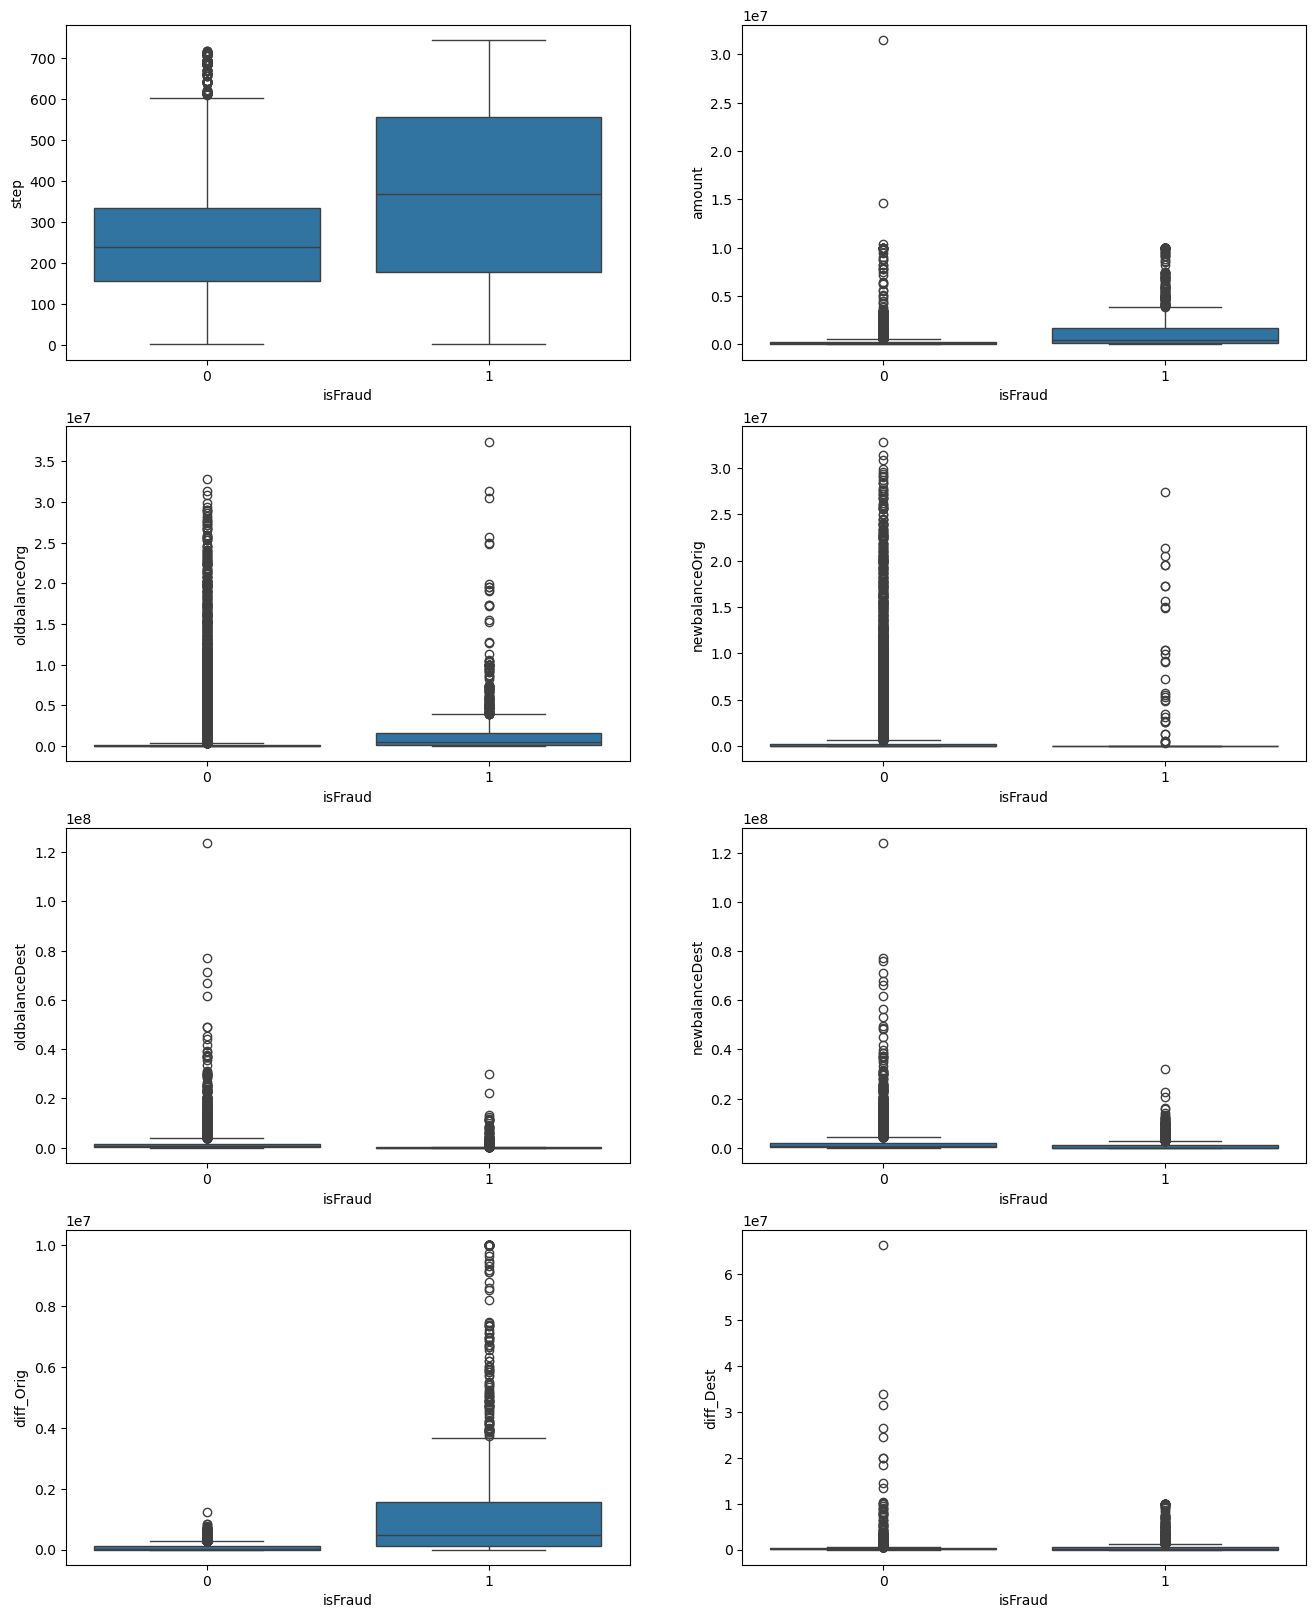

In [85]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
for i, col in enumerate(cols_to_hist+['diff_Orig','diff_Dest']):
    sns.boxplot(data=eda_C, x='isFraud', y=col, ax=axes.flatten()[i])

In [86]:
def outlier(df, cols):
    for x in cols:
        # Calculate Q1 and Q3
        Q1_x = np.percentile(df[x], 25)
        Q3_x = np.percentile(df[x], 75)
        
        # Calculate IQR
        IQR_x = Q3_x - Q1_x

        # Calculate the thresholds
        min_x = Q1_x - 1.5*IQR_x
        max_x = Q3_x + 1.5*IQR_x

        print(f"From the IQR, {x} less than {min_x} or more than {max_x} are outliers.")

In [87]:
outlier(eda_C, cols_to_hist+['diff_Orig','diff_Dest'])

From the IQR, step less than -134.0 or more than 642.0 are outliers.
From the IQR, amount less than -266978.1724999999 or more than 657974.4874999999 are outliers.
From the IQR, oldbalanceOrg less than -479615.5800000001 or more than 799359.3 are outliers.
From the IQR, newbalanceOrig less than -298083.92625 or more than 496806.54375 are outliers.
From the IQR, oldbalanceDest less than -2173789.335 or more than 3807854.885 are outliers.
From the IQR, newbalanceDest less than -2326557.5637499997 or more than 4351888.92625 are outliers.
From the IQR, diff_Orig less than -214509.94499999983 or more than 357516.5749999997 are outliers.
From the IQR, diff_Dest less than -296042.2375 or more than 637656.1825000001 are outliers.


Dari hasil di atas dapat dilihat bahwa hanya ada outlier yang bernilai terlalu tinggi, tidak ada outlier yang bernilai terlalu rendah.

### Key Insights

- Fraud hanya terjadi pada transaksi ke Customer saja (eda_C). Tidak ada data transaksi fraud pada transaksi to Merchant (eda_M).
- Fraud hanya terjadi pada transaksi berjenis TRANSFER dan CASH_OUT. Tipe transaksi lain seperti PAYMENT, CASH_IN dan DEBIT bersih dari fraud. 
- Semua data dengan isFlaggedFraud == 1 memiliki tipe transaksi TRANSFER (kemungkinan ini semua unauthorized transfer), nilai transaksi melebihi 200,000 dan semuanya menjadi transaksi fraud (isFraud == 1). Namun, jumlah data dengan isFlaggedFraud == 1 sangat sedikit sehingga tidak dapat dijadikan patokan dalam menentukan apakah transaksi fraud atau tidak.
- Beberapa transaksi baik yang normal maupun fraud memiliki nilai amount tidak sama dengan diff_Orig atau diff_Dest.
- Transaksi fraud yang nilai amount-nya ini tidak sesuai biasanya memiliki salah satu karakteristik berikut: saldo akun asal atau akun tujuan tidak bertambah atau berkurang, saldo akun tujuan bertambah jauh lebih basar dari sebelumnya.
- Korelasi antara amount dan oldbalanceOrg serta korelasi antara amount dan newbalanceOrig jauh lebih tinggi (0.89 dan 0.41). Ini artinya ada korelasi positif yang cukup kuat antara nilai transaksi dengan saldo akun asal. Semakin besar saldo akun asal, semakin besar juga nilai transaksi fraud yang terjadi. Kemungkinan transaksi fraud menguras rekening saldo akun asal.
- Outlier terjadi ketika amount bernilai lebih dari 660,000 atau diff_Orig lebih dari 360,000 atau diff_Dest lebih dari 640,000. Outlier ini akan kita kategorisasi dengan binning method untuk analisis lebih lanjut.

## Question 3

Weight of Evidence (WOE) is a technique used to transform categorical variables into numerical values based on their relationship with fraud likelihood. WOE measures how much more or less likely a particular category is to be associated with fraud compared to non-fraud. Create WOE for fraud analytics case with the following steps:
- Create categorical variable from numerical variable using binning method
- Compute WOE values for each category in that variable using the WOE formula.
- Label the strength of information using IV (Information Value) using 3 categories: [strong, weak, very low]
- Based on this result, suggest what variables can be used to detect fraudulent cases.

### Categorization

In [94]:
# Create a function for binning the numerical predictor
def create_binning(data, predictor_label, num_of_bins):
    """
    Function for binning numerical predictor.

    Parameters
    ----------
    data : array like
      The name of dataset.

    predictor_label : object
      The label of predictor variable.

    num_of_bins : integer
      The number of bins.


    Return
    ------
    data : array like
      The name of transformed dataset.

    """
    # Create a new column containing the binned predictor
    data[predictor_label + "_bin"] = pd.qcut(data[predictor_label],
                                             q = num_of_bins,
                                             duplicates = "drop")

    return data

In [95]:
# Define numerical, categorical and target columns
num_col = cols_to_hist+['diff_Orig','diff_Dest']
cat_col = ['type', 'isFlaggedFraud', 'to_Customer']
response_variable = "isFraud"

In [96]:
for column in num_col:
    data_train_binned = create_binning(data = eda_df,
                                       predictor_label = column,
                                       num_of_bins = 4)

### WOE & IV

To assess the strength of each characteristic individually as a predictor of the model.

First, create a contingency table/crosstab for all predictors: numerical and categorical predictors.

In [99]:
# Define the initial empty list
crosstab_num = []

for column in num_col:
  # Create a contingency table
  crosstab = pd.crosstab(data_train_binned[column + "_bin"],
                         data_train_binned[response_variable],
                         margins = True)
  # Append to the list
  crosstab_num.append(crosstab)


# Define the initial empty list
crosstab_cat = []

for column in cat_col:

  # Create a contingency table
  crosstab = pd.crosstab(data_train_binned[column],
                         data_train_binned[response_variable],
                         margins = True)

  # Append to the list
  crosstab_cat.append(crosstab)

# Put all two in a crosstab_list
crosstab_list = crosstab_num + crosstab_cat

for i in crosstab_list:
    display(i)

isFraud,0,1,All
step_bin,,,
"(0.999, 156.0]",3790,245,4035
"(156.0, 251.0]",3870,136,4006
"(251.0, 350.0]",3873,145,4018
"(350.0, 743.0]",3346,592,3938
All,14879,1118,15997


isFraud,0,1,All
amount_bin,,,
"(-0.001, 15050.1]",3954,46,4000
"(15050.1, 87402.86]",3853,146,3999
"(87402.86, 231701.96]",3814,185,3999
"(231701.96, 31479113.67]",3258,741,3999
All,14879,1118,15997


isFraud,0,1,All
oldbalanceOrg_bin,,,
"(-0.001, 19789.0]",7939,60,7999
"(19789.0, 152792.0]",3758,241,3999
"(152792.0, 37418265.31]",3182,817,3999
All,14879,1118,15997


isFraud,0,1,All
newbalanceOrig_bin,,,
"(-0.001, 113589.72]",10912,1086,11998
"(113589.72, 32851957.89]",3967,32,3999
All,14879,1118,15997


isFraud,0,1,All
oldbalanceDest_bin,,,
"(-0.001, 101927.16]",7183,816,7999
"(101927.16, 882801.96]",3812,187,3999
"(882801.96, 123544984.17]",3884,115,3999
All,14879,1118,15997


...

isFraud,0,1,All
diff_Orig_bin,,,
"(-0.001, 9775.14]",7940,59,7999
"(9775.14, 76190.83]",3868,131,3999
"(76190.83, 10000000.0]",3071,928,3999
All,14879,1118,15997


isFraud,0,1,All
diff_Dest_bin,,,
"(-0.001, 61910.88]",7372,627,7999
"(61910.88, 209697.74]",3889,110,3999
"(209697.74, 66308418.91]",3618,381,3999
All,14879,1118,15997


isFraud,0,1,All
type,,,
CASH_IN,3256,0,3256
CASH_OUT,5311,564,5875
DEBIT,87,0,87
PAYMENT,5007,0,5007
TRANSFER,1218,554,1772
All,14879,1118,15997


isFraud,0,1,All
isFlaggedFraud,,,
0,14879,1103,15982
1,0,15,15
All,14879,1118,15997


isFraud,0,1,All
to_Customer,,,
0,5007,0,5007
1,9872,1118,10990
All,14879,1118,15997


Next, calculate the WOE and IV for each crosstab.

- Weight of Evidence (WoE) — measures the strength of each attribute.

$$
\begin{align*}
W_i &= \ln ( \% \text{Good} / \% \text{Bad} ) \\
W_i &= \ln \left ( \left ( \frac{N_i}{\sum N} \right ) / \left ( \frac{P_i}{\sum P} \right )\right ) \\
\end{align*}
$$

- Information Value (IV) — measures the total strength of the characteristic.

$$
\begin{align*}
IV &= \sum_{i=1}^{n} ( \% \text{Good} - \% \text{Bad} ) \times W_i \\
IV &= \sum_{i=1}^{n}\left [ \left ( \frac{N_i}{\sum N} - \frac{P_i}{\sum P} \right ) \times W_i \right ] \\
\end{align*}
$$


In [101]:
# Define the initial list for WOE
WOE_list = []

# Define the initial list for IV
IV_list = []

# Perform the algorithm for all crosstab
for crosstab in crosstab_list:

  # Calculate % Good
  crosstab['p_good'] = crosstab[0]/crosstab[0]['All']

  # Calculate % Bad
  crosstab['p_bad'] = crosstab[1]/crosstab[1]['All']

  # Calculate the WOE
  crosstab['WOE'] = np.log((crosstab['p_good'] + 1e-6)/(crosstab['p_bad'] + 1e-6))  # add 1e-6 to prevent 0 division

  # Calculate the contribution value for IV
  crosstab['contribution'] = (crosstab['p_good']-crosstab['p_bad'])*crosstab['WOE']

  # Calculate the IV
  IV = crosstab['contribution'][:-1].sum()
  add_IV = {'Characteristic': crosstab.index.name,
            'Information Value': IV}

  WOE_list.append(crosstab)
  IV_list.append(add_IV)

for i in WOE_list:
    display(i)

isFraud,0,1,All,p_good,p_bad,WOE,contribution
step_bin,,,,,,,
"(0.999, 156.0]",3790,245,4035,0.254721,0.219141,0.150453,0.005353
"(156.0, 251.0]",3870,136,4006,0.260098,0.121646,0.759941,0.105216
"(251.0, 350.0]",3873,145,4018,0.260300,0.129696,0.696638,0.090984
"(350.0, 743.0]",3346,592,3938,0.224881,0.529517,-0.856393,0.260888
All,14879,1118,15997,1.000000,1.000000,0.000000,0.000000


isFraud,0,1,All,p_good,p_bad,WOE,contribution
amount_bin,,,,,,,
"(-0.001, 15050.1]",3954,46,4000,0.265744,0.041145,1.865412,0.418969
"(15050.1, 87402.86]",3853,146,3999,0.258956,0.130590,0.684587,0.087877
"(87402.86, 231701.96]",3814,185,3999,0.256334,0.165474,0.437666,0.039767
"(231701.96, 31479113.67]",3258,741,3999,0.218966,0.662791,-1.107538,0.491552
All,14879,1118,15997,1.000000,1.000000,0.000000,0.000000


isFraud,0,1,All,p_good,p_bad,WOE,contribution
oldbalanceOrg_bin,,,,,,,
"(-0.001, 19789.0]",7939,60,7999,0.533571,0.053667,2.296772,1.102229
"(19789.0, 152792.0]",3758,241,3999,0.252571,0.215564,0.158435,0.005863
"(152792.0, 37418265.31]",3182,817,3999,0.213858,0.730769,-1.228780,0.635170
All,14879,1118,15997,1.000000,1.000000,0.000000,0.000000


isFraud,0,1,All,p_good,p_bad,WOE,contribution
newbalanceOrig_bin,,,,,,,
"(-0.001, 113589.72]",10912,1086,11998,0.733383,0.971377,-0.281047,0.066888
"(113589.72, 32851957.89]",3967,32,3999,0.266617,0.028623,2.231589,0.531107
All,14879,1118,15997,1.000000,1.000000,0.000000,0.000000


isFraud,0,1,All,p_good,p_bad,WOE,contribution
oldbalanceDest_bin,,,,,,,
"(-0.001, 101927.16]",7183,816,7999,0.482761,0.729875,-0.413351,0.102145
"(101927.16, 882801.96]",3812,187,3999,0.256200,0.167263,0.426389,0.037922
"(882801.96, 123544984.17]",3884,115,3999,0.261039,0.102862,0.931273,0.147306
All,14879,1118,15997,1.000000,1.000000,0.000000,0.000000


...

isFraud,0,1,All,p_good,p_bad,WOE,contribution
diff_Orig_bin,,,,,,,
"(-0.001, 9775.14]",7940,59,7999,0.533638,0.052773,2.313705,1.112580
"(9775.14, 76190.83]",3868,131,3999,0.259964,0.117174,0.796881,0.113787
"(76190.83, 10000000.0]",3071,928,3999,0.206398,0.830054,-1.391679,0.867928
All,14879,1118,15997,1.000000,1.000000,0.000000,0.000000


isFraud,0,1,All,p_good,p_bad,WOE,contribution
diff_Dest_bin,,,,,,,
"(-0.001, 61910.88]",7372,627,7999,0.495463,0.560823,-0.123911,0.008099
"(61910.88, 209697.74]",3889,110,3999,0.261375,0.098390,0.977011,0.159238
"(209697.74, 66308418.91]",3618,381,3999,0.243162,0.340787,-0.337531,0.032952
All,14879,1118,15997,1.000000,1.000000,0.000000,0.000000


isFraud,0,1,All,p_good,p_bad,WOE,contribution
type,,,,,,,
CASH_IN,3256,0,3256,0.218832,0.000000,12.296064,2.690771
CASH_OUT,5311,564,5875,0.356946,0.504472,-0.345927,0.051033
DEBIT,87,0,87,0.005847,0.000000,8.673884,0.050718
PAYMENT,5007,0,5007,0.336515,0.000000,12.726400,4.282619
TRANSFER,1218,554,1772,0.081860,0.495528,-1.800598,0.744849
All,14879,1118,15997,1.000000,1.000000,0.000000,0.000000


isFraud,0,1,All,p_good,p_bad,WOE,contribution
isFlaggedFraud,,,,,,,
0,14879,1103,15982,1.0,0.986583,0.013508,0.000181
1,0,15,15,0.0,0.013417,-9.504339,0.127518
All,14879,1118,15997,1.0,1.000000,0.000000,0.000000


isFraud,0,1,All,p_good,p_bad,WOE,contribution
to_Customer,,,,,,,
0,5007,0,5007,0.336515,0.0,12.726400,4.282619
1,9872,1118,10990,0.663485,1.0,-0.410248,0.138054
All,14879,1118,15997,1.000000,1.0,0.000000,0.000000


In [102]:
# Put all IV in the table
IV_table = pd.DataFrame(IV_list)

IV_table

,Characteristic,Information Value
0,step_bin,0.462441
1,amount_bin,1.038165
2,oldbalanceOrg_bin,1.743262
3,newbalanceOrig_bin,0.597994
4,oldbalanceDest_bin,0.287372
5,newbalanceDest_bin,0.033685
6,diff_Orig_bin,2.094295
7,diff_Dest_bin,0.200289
8,type,7.819990
9,isFlaggedFraud,0.127699


The rule of thumb regarding IV:
- Less than 0.02 : generally unpredictive
- 0.02 to 0.1 : weak
- 0.1 to 0.3 : medium
- 0.3+ : strong

In [104]:
# Define the predictive power of each characteristic
strength = []

# Assign the rule of thumb regarding IV
for iv in IV_table['Information Value']:
    if iv < 0.02:
        strength.append('Unpredictive')
    elif iv >= 0.02 and iv < 0.1:
        strength.append('Weak')
    elif iv >= 0.1 and iv < 0.3:
        strength.append('Medium')
    else:
        strength.append('Strong')

# Assign the strength to each characteristic
IV_table = IV_table.assign(Strength = strength)

# Sort the table by the IV values
IV_table.sort_values(by='Information Value')

,Characteristic,Information Value,Strength
5,newbalanceDest_bin,0.033685,Weak
9,isFlaggedFraud,0.127699,Medium
7,diff_Dest_bin,0.200289,Medium
4,oldbalanceDest_bin,0.287372,Medium
0,step_bin,0.462441,Strong
3,newbalanceOrig_bin,0.597994,Strong
1,amount_bin,1.038165,Strong
2,oldbalanceOrg_bin,1.743262,Strong
6,diff_Orig_bin,2.094295,Strong
10,to_Customer,4.420673,Strong


We have:
- 1 weak
- 3 medium
- 7 strong characteristics

Based on this result, `step`, `newbalanceOrig`, `amount`, `oldbalanceOrg`, `diff_Orig`, `to_Customer`, `type` can be used to detect fraudulent cases.

## Question 4

One common way to detect fraud is by identifying extreme outliers. In this question, you will use two statistical methods:
- Interquartile Range (IQR): Identifies outliers based on the spread of the middle 50% of data.
- Z-score: Detects how far a value is from the mean in standard deviations.

Your task:
- Choose variables with the highest predictive power. **You can choose whether to use the WOE result or the Exploratory Data Analysis result**
- Create a simple ensemble model using the statistical approach. 
  - Use 4 variables with the highest predictive power and apply IQR method for each variable 
  - Use 3 variables with the highest predictive power and apply Z-Score method for each variable 
  - Total: there are 7 models
  - Note: it’s allowed to use the same variable in both IQR and Z-Score method
- Create a summary table and perform a majority vote. Each column represents the result of each statistical approach for predicting the outlier. 
  - Create the column for the proportion of predicted fraud over all predictions. 
  - Add 1 column for the majority vote result. 
This is an example of the result:

|Idx|IQR Var 1|IQR Var 2|...|Z Score Var 3|Proportion|Majority Vote|
|:--|:--|:--|:--|:--|:--|:--|
|0|1|1|...|1|3/7|0|
|1|0|1|...|1|5/7|1|
|2|1|1|...|1|7/7|1|
|3|0|1|...|1|6/7|1|
|4|1|1|...|0|2/7|0|

- Evaluate the model using appropriate evaluation metrics and explain the insights you got from evaluation metrics analysis

In [109]:
class IQRThreshold:
    """
    Flag fraud using IQR threshold
    """
    def fit(self, df, col, y):
        # Here we calculate the IQR of column ExpFraudLoss
        # Select col
        X = df[col].copy()

        # Extract Q1, Q3, and then IQR
        q1 = np.quantile(X, 0.25)
        q3 = np.quantile(X, 0.75)
        iqr = q3-q1

        # Obtain the threshold
        self.threshold = q3 + (1.5*iqr)

    def predict(self, df, col):
        # Predict using the given threshold
        y_pred = (df[col] > self.threshold).astype(int)

        return y_pred

In [110]:
class ZscoreThreshold:
    """
    Flag fraud using Z-score threshold
    """
    def fit(self, df, col, y):
        # Here we calculate the mean and standard deviation of column ExpFraudLoss
        # Select col
        X = df[col].copy()

        # Extract mean and standard deviation
        self.mean = X.mean()
        self.std = X.std()

        # Set the threshold (in this case, we set threshold = 2 to make significance level alpha = 2.28%)
        self.threshold = 2

    def predict(self, df, col):
        # Predict using the given threshold
        z_scores = (df[col] - self.mean) / self.std
        y_pred = (z_scores > self.threshold).astype(int)

        return y_pred

In [111]:
X = X_train
y = y_train

# 1. Tentukan variabel terpilih
iqr_vars = ['amount', 'oldbalanceOrg', 'diff_Orig', 'newbalanceOrig']
zscore_vars = ['amount', 'oldbalanceOrg', 'diff_Orig']

# Buat dataframe baru untuk menyimpan hasil voting
ensemble_df = X[['nameDest']].copy()

# Pertama, kita filter dulu transaksi to Merchant (nameDest berawalan M), tipe transaksi PAYMENT, CASH_IN, dan DEBIT karena sudah pasti bersih dari fraud.
ensemble_df['toMerchant'] = X['nameDest'].str.startswith('M')
ensemble_df['PAYMENT_CASH_IN_DEBIT'] = X['type'].isin(['PAYMENT','CASH_IN','DEBIT'])

# Lalu, kita filter juga transaksi dengan isFlaggedFraud == 1 karena sudah pasti fraud.
ensemble_df['isFlaggedFraud'] = X['isFlaggedFraud'].astype('bool')

# Kita buat dataframe baru yang tidak masuk ke 3 kategori tersebut dan memiliki kolom diff_Orig
X['diff_Orig'] = np.abs(X['newbalanceOrig'] - X['oldbalanceOrg'])
clean_df = X[~(ensemble_df['toMerchant']|ensemble_df['PAYMENT_CASH_IN_DEBIT']|ensemble_df['isFlaggedFraud'])].copy()

# 2. Terapkan IQR Method (1 jika Outlier, 0 jika Normal)
for col in iqr_vars:    
    # Create model
    IQR_clf = IQRThreshold()

    # Fit
    IQR_clf.fit(df=clean_df, col=col, y=y)
    ensemble_df[f'IQR_{col}'] = IQR_clf.predict(df=X, col=col)

# 3. Terapkan Z-Score Method (1 jika abs(Z) > threshold, 0 jika Normal)
for col in zscore_vars:
    # Create model
    Zscore_clf = ZscoreThreshold()

    # Fit
    Zscore_clf.fit(df=clean_df, col=col, y=y)
    ensemble_df[f'ZScore_{col}'] = Zscore_clf.predict(df=X, col=col)

ensemble_df['Total'] = ensemble_df['IQR_amount']+ensemble_df['IQR_oldbalanceOrg']+ensemble_df['IQR_diff_Orig']+ensemble_df['IQR_newbalanceOrig']+ensemble_df['ZScore_amount']+ensemble_df['ZScore_oldbalanceOrg']+ensemble_df['ZScore_diff_Orig']
ensemble_df['Proportion'] = ensemble_df['Total'].astype(str)+"/7"
ensemble_df['Majority Vote'] = (ensemble_df['Total']>=4).astype(int)

# Kemudian kita gabungkan Rules tadi dengan Majority Vote
# Jika nameDest berawalan M atau tipe transaksi PAYMENT, CASH_IN, dan DEBIT maka Final Prediction == 0
# Jika isFlaggedFraud == 1 maka Final Prediction == 1
# Selain itu, maka Final Prediction == Majority Vote
ensemble_df['Final Prediction'] = (~ensemble_df['toMerchant'] & ~ensemble_df['PAYMENT_CASH_IN_DEBIT'] & (ensemble_df['isFlaggedFraud'] | ensemble_df['Majority Vote'].astype(bool))).astype(int)

In [112]:
ensemble_df

,nameDest,toMerchant,PAYMENT_CASH_IN_DEBIT,isFlaggedFraud,IQR_amount,IQR_oldbalanceOrg,IQR_diff_Orig,IQR_newbalanceOrig,ZScore_amount,ZScore_oldbalanceOrg,ZScore_diff_Orig,Total,Proportion,Majority Vote,Final Prediction
5599,C1232506270,False,False,False,0,0,0,0,0,0,0,0,0/7,0,0
14173,M347065391,True,True,False,0,0,0,0,0,0,0,0,0/7,0,0
12445,M1544842379,True,True,False,0,0,0,0,0,0,0,0,0/7,0,0
2737,M946461682,True,True,False,0,0,0,0,0,0,0,0,0/7,0,0
18674,M1740352773,True,True,False,0,0,0,1,0,0,0,1,1/7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12830,M716107918,True,True,False,0,0,0,0,0,0,0,0,0/7,0,0
19607,C669850903,False,False,False,0,0,0,0,0,0,0,0,0/7,0,0
10701,C1821714221,False,False,False,0,0,0,0,0,0,0,0,0/7,0,0
16740,C2055418592,False,False,False,0,0,0,0,0,0,0,0,0/7,0,0


In [113]:
# Evaluasi Model
print("Confusion Matrix")
print(confusion_matrix(y_train, ensemble_df['Final Prediction']))

print("\nClassification Report")
print(classification_report(y_train, ensemble_df['Final Prediction']))

Confusion Matrix
[[14878     1]
 [  896   222]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     14879
           1       1.00      0.20      0.33      1118

    accuracy                           0.94     15997
   macro avg       0.97      0.60      0.65     15997
weighted avg       0.95      0.94      0.93     15997



Dari hasil di atas, dapat dilihat bahwa:
- Akurasi model sangat tinggi (0.94). Namun, akurasi model tidak menentukan baik tidaknya model dalam mendeteksi fraud.
- Nilai precision sangat tinggi (1.00). Artinya, dari 100 kasus yang diprediksi akan fraud, model dapat memprediksi hampir semua kasus dengan benar dan hampir tidak ada kasus False Positive (transaksi normal yang dianggap fraud).
- Nilai recall cukup rendah (0.20). Artinya, untuk memprediksi kasus fraud yang real, model hanya dapat memprediksi 20 kasus fraud dari 100 kasus fraud yang ada. Oleh karena itu, kita perlu membandingkan performanya dengan model Machine Learning lain untuk meningkatkan jumlah fraud yang berhasil ditangkap (Nilai recall meningkat).

## Question 5

Fraudulent transactions often behave differently from normal transactions. K-Means clustering groups similar transactions together, helping us detect anomalies.
Your task:
- Perform K-Means clustering on the dataset
- Identify the cluster with the most extreme outliers and label them as fraud.
- Visualize the clusters using scatter plots or PCA (Principal Component Analysis).
- Explain the insights you got from detecting the fraud using the clustering method

### Feature Engineering

In [118]:
X = X_train
y = y_train

# Buat dataframe baru untuk menyimpan hasil voting
kmeans_df = X[['nameDest']].copy()

# Pertama, kita filter dulu transaksi to Merchant (nameDest berawalan M), tipe transaksi PAYMENT, CASH_IN, dan DEBIT karena sudah pasti bersih dari fraud.
kmeans_df['toMerchant'] = X['nameDest'].str.startswith('M')
kmeans_df['PAYMENT_CASH_IN_DEBIT'] = X['type'].isin(['PAYMENT','CASH_IN','DEBIT'])

# Lalu, kita filter juga transaksi dengan isFlaggedFraud == 1 karena sudah pasti fraud.
kmeans_df['isFlaggedFraud'] = X['isFlaggedFraud'].astype('bool')

# Kita buat dataframe baru yang tidak masuk ke 3 kategori tersebut dan memiliki kolom diff_Orig
X['diff_Orig'] = np.abs(X['newbalanceOrig'] - X['oldbalanceOrg'])
clean_df = X[~(kmeans_df['toMerchant']|kmeans_df['PAYMENT_CASH_IN_DEBIT']|kmeans_df['isFlaggedFraud'])].copy()

# Ambil kolom yang dibutuhkan saja, kita ambil 6 kolom numerik
features = ['amount', 'oldbalanceOrg', 'diff_Orig', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
clean_df = clean_df[features]

# Standardisasi Data (Sangat disarankan untuk algoritma berbasis jarak seperti K-Means)
scaler = StandardScaler().set_output(transform="pandas")
scaled_df = scaler.fit_transform(clean_df)
scaled_df.describe()

,amount,oldbalanceOrg,diff_Orig,newbalanceOrig,oldbalanceDest,newbalanceDest
count,7.632000e+03,7.632000e+03,7.632000e+03,7.632000e+03,7.632000e+03,7.632000e+03
mean,3.630918e-17,-2.327512e-18,2.420612e-17,3.724019e-18,6.982535e-18,5.120525e-17
std,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00
min,-3.927523e-01,-1.995030e-01,-2.297282e-01,-5.779740e-02,-4.153886e-01,-4.688773e-01
25%,-3.202311e-01,-1.995030e-01,-2.297282e-01,-5.779740e-02,-4.045127e-01,-4.065385e-01
50%,-2.433202e-01,-1.951123e-01,-2.246569e-01,-5.779740e-02,-2.997911e-01,-2.937119e-01
75%,-1.044056e-01,-1.479687e-01,-1.771969e-01,-5.779740e-02,-7.225538e-04,1.991317e-02
max,2.520681e+01,2.731117e+01,9.476275e+00,4.565755e+01,3.293822e+01,2.926311e+01


### K-Means Clustering

**Goal**: make separate group with similar character, and assign them into cluster, detect farthest observation from centroid as anomaly

*try some k values*

In [122]:
score_list = []
k_list = np.arange(2, 11, 1)
X=scaled_df

for k in k_list:
    # Buat object
    kmeans_obj_k = KMeans(n_clusters = k,
                          max_iter = 50,
                          random_state = 123,
                          n_init = 'auto')

    # Fit data
    kmeans_obj_k.fit(X)

    # update score
    score_k = -kmeans_obj_k.score(X)
    score_list.append(score_k)
score_list

[30410.27467520329,
 22693.494177167748,
 15541.590941092198,
 12142.816691945825,
 11268.713093831902,
 9511.606781785942,
 7298.850201850386,
 6359.644924884443,
 5806.1921697403695]

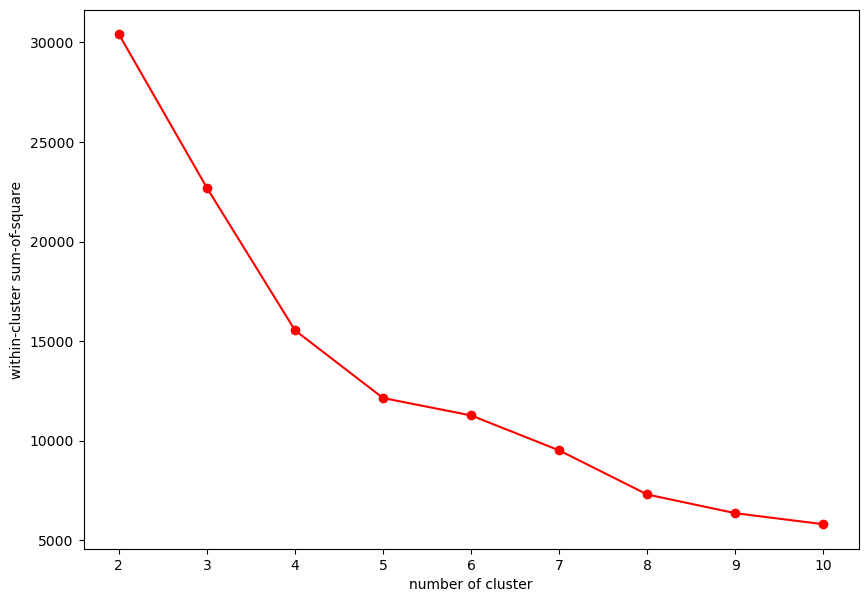

In [123]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 7))

ax.plot(k_list, score_list, "r", marker="o")

ax.set_xlabel("number of cluster")
ax.set_ylabel("within-cluster sum-of-square")
plt.show()

- The more clusters, the lower the score.
- But, the more clusters, the more complex it is to interpret.
- We try to take the best number of cluster at 4, because the error change in five clusters is smaller

In [125]:
# Create object
kmeans_obj_best = KMeans(n_clusters = 4,
                         random_state = 123,
                         n_init = 'auto')

# Fit object
kmeans_obj_best.fit(scaled_df)

KMeans(n_clusters=4, n_init='auto', random_state=123)

**Predict Cluster**

In [127]:
cluster_best_train = kmeans_obj_best.predict(scaled_df)

cluster_best_train = pd.DataFrame(data = cluster_best_train,
                            columns = ["cluster"],
                            index= scaled_df.index)
cluster_best_train.head()

final_df = scaled_df.copy()
final_df['Cluster'] = cluster_best_train
final_df

,amount,oldbalanceOrg,diff_Orig,newbalanceOrig,oldbalanceDest,newbalanceDest,Cluster
5599,-0.297085,-0.199503,-0.229728,-0.057797,0.290922,0.187249,1
14569,-0.262976,-0.127834,-0.135115,-0.057797,-0.415389,-0.430578,1
10643,-0.369835,-0.199503,-0.229728,-0.057797,-0.244290,-0.310011,1
451,-0.381088,-0.188958,-0.215807,-0.057797,0.351982,0.216740,1
11272,-0.137150,-0.125513,-0.132051,-0.057797,-0.076223,-0.091934,1
...,...,...,...,...,...,...,...
16497,-0.218937,-0.192162,-0.220037,-0.057797,-0.289072,-0.305289,1
18918,-0.259943,-0.199503,-0.229728,-0.057797,0.322225,0.226039,1
19607,-0.197428,-0.199503,-0.229728,-0.057797,0.535538,0.434118,1
10701,-0.345918,-0.199503,-0.229728,-0.057797,-0.149954,-0.219090,1


**Show Centroid**

In [129]:
# Create dataframe
centroids_best = kmeans_obj_best.cluster_centers_
centroids_best = pd.DataFrame(data = centroids_best,
                              columns = scaled_df.columns)

centroids_best

,amount,oldbalanceOrg,diff_Orig,newbalanceOrig,oldbalanceDest,newbalanceDest
0,0.883410,-0.145538,-0.164390,-0.047656,4.037605,4.033370
1,-0.128832,-0.107947,-0.121493,-0.036097,-0.116806,-0.133066
2,7.739486,18.838275,9.476275,26.442730,-0.415389,-0.468877
3,4.898358,4.721565,6.085327,0.253966,-0.291805,0.580820


Dari sini dapat dilihat bahwa cluster 2 memiliki nilai `amount`,`oldbalanceOrg`,`diff_Orig`,`newbalanceOrig` yang jauh lebih tinggi dibanding cluster yang lain. Jadi, kita akan anggap cluster 2 memiliki banyak nilai outlier dan kita anggap sebagai fraud. \
Selain itu, kita akan coba mendeteksi outlier dengan melihat distance dari tiap centroid.

In [131]:
# return Series of distance between each point and its distance with the closest centroid
def getDistanceByPoint(data, model):

    distance = pd.Series(dtype='float64')
    data = data.reset_index(drop = True)

    # iterate over each data
    for i in range(0, len(data)):
        Xa = np.array(data.loc[i])
        Xb = model.cluster_centers_[model.labels_[i]-1]

        # Calculate distance between data and the centroid
        distance.at[i] = np.linalg.norm(Xa-Xb)

    return distance

In [132]:
# Get the distance between each point and its nearest centroid.
# The biggest distances are considered as anomaly
distance = getDistanceByPoint(scaled_df,
                              kmeans_obj_best)
distance

0       5.498285
1       6.408702
2       6.227158
3       5.454729
4       5.914796
          ...   
7627    6.226125
7628    5.441907
7629    5.137566
7630    6.094062
7631    6.345613
Length: 7632, dtype: float64

In [133]:
# Assume a values as an outlier / anomaly fraction from all data
outliers_fraction = 0.02

# Get the number of outliers based on the fraction we assume
number_of_outliers = int(outliers_fraction * len(distance))
number_of_outliers

152

In [134]:
# Get the threshold based on the number of outlier
threshold = distance.nlargest(number_of_outliers).min()
threshold

18.773394574690812

In [135]:
#`anomaly` contain the anomaly result of the above method Cluster (0 : normal, 1 : anomaly)
anomaly = np.array((distance >= threshold).astype(int))
anomaly

array([0, 0, 0, ..., 0, 0, 0])

Get anomaly data statistics description

In [137]:
final_df.iloc[np.where(anomaly == 1)].describe()

,amount,oldbalanceOrg,diff_Orig,newbalanceOrig,oldbalanceDest,newbalanceDest,Cluster
count,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000
mean,5.061848,5.281615,5.974055,1.715194,0.514904,1.281250,2.802632
std,2.771624,4.157318,2.709999,6.768718,4.044007,3.808453,0.661520
min,-0.365586,-0.199503,-0.229728,-0.057797,-0.415389,-0.468877,0.000000
25%,3.039147,2.867357,3.818983,-0.057797,-0.415389,-0.468877,3.000000
50%,4.456551,4.144055,5.504414,-0.057797,-0.415389,0.501767,3.000000
75%,7.739486,7.007038,9.283977,-0.057797,-0.352406,1.580482,3.000000
max,25.206813,27.311172,9.476275,45.657555,32.938215,29.263108,3.000000


In [138]:
final_df.iloc[np.where(anomaly == 1)]['Cluster'].value_counts()

Cluster
3    136
2      9
0      7
Name: count, dtype: int64

Dari sini, dapat dilihat Cluster 3 dan Cluster 2 memiliki nilai outlier paling banyak. Jadi, kita akan anggap semua data dalam cluster tersebut sebagai fraud.

Compare with original data

In [141]:
final_df.describe()

,amount,oldbalanceOrg,diff_Orig,newbalanceOrig,oldbalanceDest,newbalanceDest,Cluster
count,7.632000e+03,7.632000e+03,7.632000e+03,7.632000e+03,7.632000e+03,7.632000e+03,7632.000000
mean,3.630918e-17,-2.327512e-18,2.420612e-17,3.724019e-18,6.982535e-18,5.120525e-17,1.008124
std,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,0.319197
min,-3.927523e-01,-1.995030e-01,-2.297282e-01,-5.779740e-02,-4.153886e-01,-4.688773e-01,0.000000
25%,-3.202311e-01,-1.995030e-01,-2.297282e-01,-5.779740e-02,-4.045127e-01,-4.065385e-01,1.000000
50%,-2.433202e-01,-1.951123e-01,-2.246569e-01,-5.779740e-02,-2.997911e-01,-2.937119e-01,1.000000
75%,-1.044056e-01,-1.479687e-01,-1.771969e-01,-5.779740e-02,-7.225538e-04,1.991317e-02,1.000000
max,2.520681e+01,2.731117e+01,9.476275e+00,4.565755e+01,3.293822e+01,2.926311e+01,3.000000


In [142]:
final_df['Cluster'].value_counts()

Cluster
1    7265
0     221
3     137
2       9
Name: count, dtype: int64

### Visualisasi dengan PCA

In [144]:
# Menambahkan kolom 'isFraud'
final_df['isFraud'] = y
final_df

,amount,oldbalanceOrg,diff_Orig,newbalanceOrig,oldbalanceDest,newbalanceDest,Cluster,isFraud
5599,-0.297085,-0.199503,-0.229728,-0.057797,0.290922,0.187249,1,0
14569,-0.262976,-0.127834,-0.135115,-0.057797,-0.415389,-0.430578,1,0
10643,-0.369835,-0.199503,-0.229728,-0.057797,-0.244290,-0.310011,1,0
451,-0.381088,-0.188958,-0.215807,-0.057797,0.351982,0.216740,1,1
11272,-0.137150,-0.125513,-0.132051,-0.057797,-0.076223,-0.091934,1,0
...,...,...,...,...,...,...,...,...
16497,-0.218937,-0.192162,-0.220037,-0.057797,-0.289072,-0.305289,1,0
18918,-0.259943,-0.199503,-0.229728,-0.057797,0.322225,0.226039,1,0
19607,-0.197428,-0.199503,-0.229728,-0.057797,0.535538,0.434118,1,0
10701,-0.345918,-0.199503,-0.229728,-0.057797,-0.149954,-0.219090,1,0


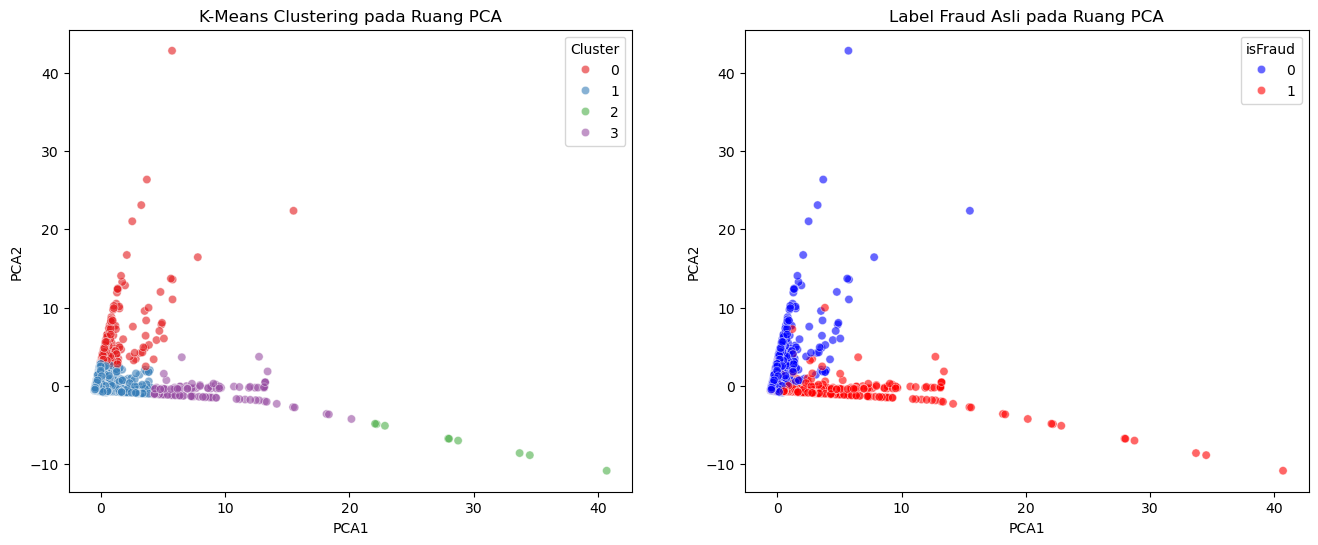

In [145]:
# Visualisasi dengan PCA (Mereduksi 6 dimensi menjadi 2 dimensi)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df)

final_df['PCA1'] = pca_result[:, 0]
final_df['PCA2'] = pca_result[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot 1: Hasil Klasterisasi K-Means
sns.scatterplot(data=final_df, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', alpha=0.6, ax=axes[0])
axes[0].set_title('K-Means Clustering pada Ruang PCA')

# Scatter Plot 2: Label Fraud Asli ('isFraud')
sns.scatterplot(data=final_df, x='PCA1', y='PCA2', hue='isFraud', palette={0: 'blue', 1: 'red'}, alpha=0.6, ax=axes[1])
axes[1].set_title('Label Fraud Asli pada Ruang PCA')

plt.show()

### Key Insights

In [147]:
real_centroids =pd.DataFrame(scaler.inverse_transform(centroids_best), columns = features)
real_centroids.style.format("{:.2f}")

,amount,oldbalanceOrg,diff_Orig,newbalanceOrig,oldbalanceDest,newbalanceDest
0,1569262.86,73399.40,67317.00,6082.40,16494320.85,18759509.67
1,324535.89,124528.68,111513.74,13014.94,1105979.37,1399223.13
2,10000000.00,25893971.50,10000000.00,15893971.50,0.00,0.00
3,6506339.82,6693323.27,6506339.82,186983.44,457764.55,4373773.63


Dari hasil di atas, dapat dilihat bahwa:
- Data dapat dibagi menjadi 4 cluster:
  - Cluster 0: Transaksi dengan saldo akun tujuan yang paling tinggi dibandingkan cluster lainnya dan nilai transaksi menengah
  - Cluster 1: Transaksi dengan nilai transaksi paling rendah
  - Cluster 2: Transaksi dengan nilai `amount`,`oldbalanceOrg`,`diff_Orig`,`newbalanceOrig` yang jauh lebih tinggi dibanding cluster yang lain, dan saldo akun tujuan paling rendah dibanding cluster yang lain
  - Cluster 3: Transaksi dengan nilai transaksi dan selisih akun saldo asal yang lebih tinggi dari Cluster 0 dan 1, namun lebih rendah dari Cluster 2
- Dari hasil PCA, dapat dilihat bahwa sebagian besar Cluster 2 dan Cluster 3 masuk ke dalam kategori Fraud.
- Akan tetapi, K-Means Clustering tidak berhasil mendeteksi sebagian besar kasus fraud lainnya karena sebagian besar transaksi fraud masuk ke dalam Cluster 1 (transaksi dengan nominal rendah) jika dilihat dari hasil PCA.
- Oleh karena itu, pendekatan deteksi fraud melalui clustering saja tidak cukup dan perlu analisis lebih lanjut.

## Question 6

Once we have built fraud detection models, we need to evaluate their effectiveness. Different models may have trade-offs between catching fraud and avoiding false alarms. Your Task is to compare the fraud detection models built so far (statistical, K-Means). Use the following metrics:
- Precision (How many predicted fraud cases are actually fraud?)
- Recall (How many actual fraud cases did we catch?)
- F1-score (Balance between precision and recall)
- Explain results of the strengths and weaknesses of each approach.

### Final Prediction for Statistical Model

In [152]:
# Evaluasi Model
print("Confusion Matrix")
print(confusion_matrix(y_train, ensemble_df['Final Prediction']))

print("\nClassification Report")
print(classification_report(y_train, ensemble_df['Final Prediction']))

Confusion Matrix
[[14878     1]
 [  896   222]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     14879
           1       1.00      0.20      0.33      1118

    accuracy                           0.94     15997
   macro avg       0.97      0.60      0.65     15997
weighted avg       0.95      0.94      0.93     15997



### Final Prediction for K-Means Clustering

In [154]:
# Gabungkan hasil cluster dengan dataframe yang telah dibuat
kmeans_df = kmeans_df.join(final_df['Cluster'])
kmeans_df

,nameDest,toMerchant,PAYMENT_CASH_IN_DEBIT,isFlaggedFraud,Cluster
5599,C1232506270,False,False,False,1.0
14173,M347065391,True,True,False,NaN
12445,M1544842379,True,True,False,NaN
2737,M946461682,True,True,False,NaN
18674,M1740352773,True,True,False,NaN
...,...,...,...,...,...
12830,M716107918,True,True,False,NaN
19607,C669850903,False,False,False,1.0
10701,C1821714221,False,False,False,1.0
16740,C2055418592,False,False,False,1.0


In [155]:
# Kemudian kita gabungkan Rules tadi dengan Majority Vote
# Jika nameDest berawalan M atau tipe transaksi PAYMENT, CASH_IN, dan DEBIT maka Final Prediction == 0
# Jika isFlaggedFraud == 1 maka Final Prediction == 1
# Selain itu, maka Final Prediction == 1 ketika data di cluster 2 atau 3
kmeans_df['Final Prediction'] = (~kmeans_df['toMerchant'] & ~kmeans_df['PAYMENT_CASH_IN_DEBIT'] & (kmeans_df['isFlaggedFraud'] | kmeans_df['Cluster'].isin([2,3]))).astype(int)
kmeans_df

,nameDest,toMerchant,PAYMENT_CASH_IN_DEBIT,isFlaggedFraud,Cluster,Final Prediction
5599,C1232506270,False,False,False,1.0,0
14173,M347065391,True,True,False,NaN,0
12445,M1544842379,True,True,False,NaN,0
2737,M946461682,True,True,False,NaN,0
18674,M1740352773,True,True,False,NaN,0
...,...,...,...,...,...,...
12830,M716107918,True,True,False,NaN,0
19607,C669850903,False,False,False,1.0,0
10701,C1821714221,False,False,False,1.0,0
16740,C2055418592,False,False,False,1.0,0


In [156]:
# Evaluasi Model
print("Confusion Matrix")
print(confusion_matrix(y_train, kmeans_df['Final Prediction']))

print("\nClassification Report")
print(classification_report(y_train, kmeans_df['Final Prediction']))

Confusion Matrix
[[14879     0]
 [  957   161]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     14879
           1       1.00      0.14      0.25      1118

    accuracy                           0.94     15997
   macro avg       0.97      0.57      0.61     15997
weighted avg       0.94      0.94      0.92     15997



### Summary

In [158]:
def model_summary(model_name, y, y_pred):
    
    # Get the classification report
    eval_dict = classification_report(y, y_pred, output_dict=True)

    # Find all metrics
    accuracy_ = eval_dict['accuracy']
    recall_ = eval_dict['1']['recall']
    precision_ = eval_dict['1']['precision']
    f1_ = eval_dict['1']['f1-score']

    # Get into dataframe
    summary = pd.DataFrame(
        [[accuracy_, recall_, precision_, f1_]],
        columns = ["Accuracy", "Recall", "Precision", "F1-Score"],
        index = [model_name]
    )

    return summary

In [159]:
summary_stats = model_summary("Statistical Approach", y_train, ensemble_df['Final Prediction'])
summary_kmeans = model_summary("K-Means Clustering", y_train, kmeans_df['Final Prediction'])
# Add to summary evaluation train
summary_evaluation_train = pd.concat((summary_stats, summary_kmeans),
                                     axis=0)
summary_evaluation_train

,Accuracy,Recall,Precision,F1-Score
Statistical Approach,0.943927,0.198569,0.995516,0.331096
K-Means Clustering,0.940176,0.144007,1.000000,0.251759


Dari hasil di atas, dapat dilihat bahwa: 

Kelebihan Model Statistical Approach:
- Model ini berfokus pada pencarian nilai outlier (nilai yang jauh lebih besar dari rata-rata).
- Nilai accuracy sangat tinggi (0.94). Namun, akurasi model tidak menentukan baik tidaknya model dalam mendeteksi fraud.
- Nilai precision juga sangat tinggi (0.996). Artinya, dari 1000 kasus yang diprediksi akan fraud, model dapat memprediksi 996 kasus dengan benar dan hanya ada 4 kasus False Positive (transaksi normal yang dianggap fraud).

Kekurangan Model Statistical Approach:
- Nilai recall sangat rendah (0.199) meskipun lebih tinggi dari model K-Means. Artinya, untuk memprediksi kasus fraud yang real, model hanya dapat memprediksi 199 fraud dari 1000 kasus fraud yang ada.
- Nilai f1-score juga cukup rendah (0.331) meskipun lebih tinggi dari model K-Means. Artinya, model memiliki nilai yang tidak seimbang antara precision dan recall (karena precision sangat tinggi nilainya tetapi recall sangat rendah).

Kelebihan Model K-Means Clustering:
- Model ini berfokus pada pengelompokkan transaksi berdasarkan kemiripan jarak dari centroid tiap cluster tanpa perlu memberikan label awal.
- Nilai accuracy sangat tinggi (0.94). Namun, akurasi model tidak menentukan baik tidaknya model dalam mendeteksi fraud.
- Nilai precision (1.000) lebih tinggi dari model statistik. Artinya, dari 1000 kasus yang diprediksi akan fraud, model dapat memprediksi semua 1000 kasus dengan benar dan tidak ada kasus False Positive (transaksi normal yang dianggap fraud).

Kekurangan Model K-Means Clustering:
- Nilai recall (0.144) lebih rendah dari model statistik. Artinya, untuk memprediksi kasus fraud yang real, model hanya dapat memprediksi 144 fraud dari 1000 kasus fraud yang ada.
- Nilai f1-score juga lebih rendah (0.252) dari model statistik. Artinya, model memiliki nilai yang lebih tidak seimbang antara precision dan recall (karena precision sangat tinggi nilainya tetapi recall sangat rendah).

## Question 7

Ensemble models combine multiple models to make a better prediction. Instead of relying on just one method (e.g., statistical approach or K-Means), combine different models and take a majority vote to decide if a transaction is fraud. 

Create 3 models:

**Model 1**: Create an ensemble fraud detection model using statistical method only
- Use 3 variables with the highest predictive power and apply **IQR method** for each variable 
- Create a summary table and perform a majority vote. This is an example of the result:

|Idx|IQR Var 1|IQR Var 2|IQR Var 3|Proportion|Majority Vote|
|:--|:--|:--|:--|:--|:--|
|0|1|1|1|3/3|1|
|1|0|1|1|2/3|1|
|2|0|0|0|0/3|0|
|3|0|1|0|1/3|0|
|4|1|1|0|2/3|1|

- Evaluate the model using appropriate evaluation metrics

**Model 2**: Create an ensemble fraud detection model using statistical method only
- Use 3 variables with the highest predictive power and **apply Z-Score** method for each variable 
- Create a summary table and perform a majority vote.  This is an example of the result:

|Idx|Z Score Var 1|Z Score Var 2|Z Score Var 3|Proportion|Majority Vote|
|:--|:--|:--|:--|:--|:--|
|0|1|0|1|2/3|1|
|1|0|1|1|2/3|1|
|2|0|0|0|0/3|0|
|3|0|1|1|2/3|1|
|4|0|0|0|0/3|0|

- Evaluate the model using appropriate evaluation metrics

**Model 3**: Create an ensemble fraud detection model by **combining Statistical methods (IQR, Z-score) and Clustering methods (K-Means)**
- Define a decision rule: If the majority of models classify a transaction as fraud, label it as fraud.
- This is an example of the result:

|Idx|Model 1|Model 2|K-Means|Proportion|Majority Vote|
|:--|:--|:--|:--|:--|:--|
|0|1|0|1|1/3|0|
|1|0|1|1|2/3|1|
|2|0|0|0|0/3|0|
|3|0|1|0|1/3|0|
|4|0|0|1|1/3|0|

- Evaluate the model using appropriate evaluation metrics

Test which model performs better than other models. 
- Compare the result of model 1 and model 2 (ensemble model from statistical approach only) vs model 3 (ensemble model from combined between ensemble statistical and clustering method). 
- This is an example of the table of the comparison:

|Model name|Evaluation Metrics|
|:--|:--|
|Model 1|0.65|
|Model 2|0.70|
|Model 3|0.72|

### Model 1 - Statistical Approach: IQR

In [164]:
model_1 = ensemble_df[['toMerchant','PAYMENT_CASH_IN_DEBIT','isFlaggedFraud','IQR_amount','IQR_oldbalanceOrg','IQR_diff_Orig']].copy()
model_1['Total'] = model_1['IQR_amount']+model_1['IQR_oldbalanceOrg']+model_1['IQR_diff_Orig']
model_1['Proportion'] = model_1['Total'].astype(str)+"/3"
model_1['Majority Vote'] = (model_1['Total']>=2).astype(int)

# Kemudian kita gabungkan Rules tadi dengan Majority Vote
# Jika nameDest berawalan M atau tipe transaksi PAYMENT, CASH_IN, dan DEBIT maka Final Prediction == 0
# Jika isFlaggedFraud == 1 maka Final Prediction == 1
# Selain itu, maka Final Prediction == Majority Vote
model_1['Final Prediction'] = (~model_1['toMerchant'] & ~model_1['PAYMENT_CASH_IN_DEBIT'] & (model_1['isFlaggedFraud'] | model_1['Majority Vote'].astype(bool))).astype(int)
model_1

,toMerchant,PAYMENT_CASH_IN_DEBIT,isFlaggedFraud,IQR_amount,IQR_oldbalanceOrg,IQR_diff_Orig,Total,Proportion,Majority Vote,Final Prediction
5599,False,False,False,0,0,0,0,0/3,0,0
14173,True,True,False,0,0,0,0,0/3,0,0
12445,True,True,False,0,0,0,0,0/3,0,0
2737,True,True,False,0,0,0,0,0/3,0,0
18674,True,True,False,0,0,0,0,0/3,0,0
...,...,...,...,...,...,...,...,...,...,...
12830,True,True,False,0,0,0,0,0/3,0,0
19607,False,False,False,0,0,0,0,0/3,0,0
10701,False,False,False,0,0,0,0,0/3,0,0
16740,False,False,False,0,0,0,0,0/3,0,0


In [165]:
# Evaluasi Model
print("Confusion Matrix")
print(confusion_matrix(y_train, model_1['Final Prediction']))

print("\nClassification Report")
print(classification_report(y_train, model_1['Final Prediction']))

Confusion Matrix
[[14602   277]
 [  328   790]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     14879
           1       0.74      0.71      0.72      1118

    accuracy                           0.96     15997
   macro avg       0.86      0.84      0.85     15997
weighted avg       0.96      0.96      0.96     15997



### Model 2 - Statistical Approach: Z-Score

In [167]:
model_2 = ensemble_df[['toMerchant','PAYMENT_CASH_IN_DEBIT','isFlaggedFraud','ZScore_amount','ZScore_oldbalanceOrg','ZScore_diff_Orig']].copy()
model_2['Total'] = model_2['ZScore_amount']+model_2['ZScore_oldbalanceOrg']+model_2['ZScore_diff_Orig']
model_2['Proportion'] = model_2['Total'].astype(str)+"/3"
model_2['Majority Vote'] = (model_2['Total']>=2).astype(int)

# Kemudian kita gabungkan Rules tadi dengan Majority Vote
# Jika nameDest berawalan M atau tipe transaksi PAYMENT, CASH_IN, dan DEBIT maka Final Prediction == 0
# Jika isFlaggedFraud == 1 maka Final Prediction == 1
# Selain itu, maka Final Prediction == Majority Vote
model_2['Final Prediction'] = (~model_2['toMerchant'] & ~model_2['PAYMENT_CASH_IN_DEBIT'] & (model_2['isFlaggedFraud'] | model_2['Majority Vote'].astype(bool))).astype(int)
model_2

,toMerchant,PAYMENT_CASH_IN_DEBIT,isFlaggedFraud,ZScore_amount,ZScore_oldbalanceOrg,ZScore_diff_Orig,Total,Proportion,Majority Vote,Final Prediction
5599,False,False,False,0,0,0,0,0/3,0,0
14173,True,True,False,0,0,0,0,0/3,0,0
12445,True,True,False,0,0,0,0,0/3,0,0
2737,True,True,False,0,0,0,0,0/3,0,0
18674,True,True,False,0,0,0,0,0/3,0,0
...,...,...,...,...,...,...,...,...,...,...
12830,True,True,False,0,0,0,0,0/3,0,0
19607,False,False,False,0,0,0,0,0/3,0,0
10701,False,False,False,0,0,0,0,0/3,0,0
16740,False,False,False,0,0,0,0,0/3,0,0


In [168]:
# Evaluasi Model
print("Confusion Matrix")
print(confusion_matrix(y_train, model_2['Final Prediction']))

print("\nClassification Report")
print(classification_report(y_train, model_2['Final Prediction']))

Confusion Matrix
[[14879     0]
 [  941   177]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     14879
           1       1.00      0.16      0.27      1118

    accuracy                           0.94     15997
   macro avg       0.97      0.58      0.62     15997
weighted avg       0.94      0.94      0.92     15997



### Model 3 - Ensemble Model from Statistical and Clustering method

In [170]:
model_3 = pd.DataFrame()
model_3['Model 1'] = model_1['Final Prediction'].copy()
model_3['Model 2'] = model_2['Final Prediction'].copy()
model_3['K-Means'] = kmeans_df['Final Prediction'].copy()

model_3['Total'] = model_3['Model 1']+model_3['Model 2']+model_3['K-Means']
model_3['Proportion'] = model_3['Total'].astype(str)+"/3"
model_3['Majority Vote'] = (model_3['Total']>=2).astype(int)
model_3

,Model 1,Model 2,K-Means,Total,Proportion,Majority Vote
5599,0,0,0,0,0/3,0
14173,0,0,0,0,0/3,0
12445,0,0,0,0,0/3,0
2737,0,0,0,0,0/3,0
18674,0,0,0,0,0/3,0
...,...,...,...,...,...,...
12830,0,0,0,0,0/3,0
19607,0,0,0,0,0/3,0
10701,0,0,0,0,0/3,0
16740,0,0,0,0,0/3,0


In [171]:
# Evaluasi Model
print("Confusion Matrix")
print(confusion_matrix(y_train, model_3['Majority Vote']))

print("\nClassification Report")
print(classification_report(y_train, model_3['Majority Vote']))

Confusion Matrix
[[14879     0]
 [  941   177]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     14879
           1       1.00      0.16      0.27      1118

    accuracy                           0.94     15997
   macro avg       0.97      0.58      0.62     15997
weighted avg       0.94      0.94      0.92     15997



### Summary

In [173]:
summary_1 = model_summary("Model 1", y_train, model_1['Final Prediction'])
summary_2 = model_summary("Model 2", y_train, model_2['Final Prediction'])
summary_3 = model_summary("Model 3", y_train, model_3['Majority Vote'])
# Add to summary evaluation train
summary_evaluation_train = pd.concat((summary_1, summary_2, summary_3),
                                     axis=0)
summary_evaluation_train

,Accuracy,Recall,Precision,F1-Score
Model 1,0.962180,0.706619,0.740394,0.723112
Model 2,0.941176,0.158318,1.000000,0.273359
Model 3,0.941176,0.158318,1.000000,0.273359


Dari hasil di atas, dapat dilihat bahwa Model 1 memiliki performa lebih baik dari model lainnya. \
Meskipun precisionnya lebih rendah (0.74), nilai recall dan f1-score model 1 jauh lebih tinggi dari model lainnya. \
Model 1 memiliki nilai recall sebesar 0.707, artinya untuk memprediksi kasus fraud yang real, model 1 dapat memprediksi 707 fraud dari 1000 kasus fraud yang ada. Dibandingkan model lain yang hanya memiliki nilai recall sebesar 0.158, artinya untuk memprediksi kasus fraud yang real, model 2 dan 3 hanya dapat memprediksi 158 fraud dari 1000 kasus fraud yang ada.

## Question 8

Make a simulation on cost and ROI based on this condition:

- You proposed a fraud detection model to minimize fraud losses based on the best model obtained from the previous number
- However, beyond cost savings, you must also consider benefits, model ownership costs, and fraud handling costs. **ROI** is calculated as the ratio of net profit (benefit minus costs) to total investment, expressed as a percentage. \
$$
\text{ROI} = \frac{\text{Total Utility}}{\text{Total cost of ownership} + \text{Total cost of fraud handling}}
$$

- **Total utility** is defined as the difference between benefits and costs, representing the net return. 
  - Costs are as follows:
    - False Negatives (FN): Fraud loss, represented by the corresponding transaction amount for ignored fraud cases.
    - False Positives (FP): Losses from profit and customer acquisition costs, including 30,000 for acquisition and 70,000 for-profit loss per false positive.
  - Benefits include: 
    - True Positives (TP): Prevented fraud losses, represented by the corresponding transaction amount.
    - True Negatives (TN): Generated profit of 70,000 from legitimate transactions.

- The **total cost of ownership** consists of acquisition costs (500,000,000 for software, hardware, security, and development) and operation costs (300,000,000 for migration, setup, monitoring, and support).
- **Total Cost of Fraud Handling** includes handling and legal costs. Assume: 
  - Fraud handling cost per transaction is 200,000 
  - Legal cost: 5,000,000

### Test Set
___

Dari hasil Question 7, kita akan memilih model 1 sebagai model terbaik.

In [179]:
X = X_test
y = y_test

# 1. Tentukan variabel terpilih
iqr_vars = ['amount', 'oldbalanceOrg', 'diff_Orig']

# Buat dataframe baru untuk menyimpan hasil voting
test_df = X[['nameDest']].copy()

# Pertama, kita filter dulu transaksi to Merchant (nameDest berawalan M), tipe transaksi PAYMENT, CASH_IN, dan DEBIT karena sudah pasti bersih dari fraud.
test_df['toMerchant'] = X['nameDest'].str.startswith('M')
test_df['PAYMENT_CASH_IN_DEBIT'] = X['type'].isin(['PAYMENT','CASH_IN','DEBIT'])

# Lalu, kita filter juga transaksi dengan isFlaggedFraud == 1 karena sudah pasti fraud.
test_df['isFlaggedFraud'] = X['isFlaggedFraud'].astype('bool')

# Kita buat dataframe baru yang tidak masuk ke 3 kategori tersebut dan memiliki kolom diff_Orig
X['diff_Orig'] = np.abs(X['newbalanceOrig'] - X['oldbalanceOrg'])

# Ambil data train yang telah dibuat sebelumnya
clean_df = X_train[~(ensemble_df['toMerchant']|ensemble_df['PAYMENT_CASH_IN_DEBIT']|ensemble_df['isFlaggedFraud'])].copy()

# 2. Terapkan IQR Method (1 jika Outlier, 0 jika Normal)
for col in iqr_vars:
    # Create model
    IQR_clf = IQRThreshold()

    # Fit dengan data train
    IQR_clf.fit(df=clean_df, col=col, y=y)

    # Predict data test
    test_df[f'IQR_{col}'] = IQR_clf.predict(df=X, col=col)

test_df['Total'] = test_df['IQR_amount']+test_df['IQR_oldbalanceOrg']+test_df['IQR_diff_Orig']
test_df['Proportion'] = test_df['Total'].astype(str)+"/3"
test_df['Majority Vote'] = (test_df['Total']>=2).astype(int)

# Kemudian kita gabungkan Rules tadi dengan Majority Vote
# Jika nameDest berawalan M atau tipe transaksi PAYMENT, CASH_IN, dan DEBIT maka Final Prediction == 0
# Jika isFlaggedFraud == 1 maka Final Prediction == 1
# Selain itu, maka Final Prediction == Majority Vote
test_df['Final Prediction'] = (~test_df['toMerchant'] & ~test_df['PAYMENT_CASH_IN_DEBIT'] & (test_df['isFlaggedFraud'] | test_df['Majority Vote'].astype(bool))).astype(int)
test_df

,nameDest,toMerchant,PAYMENT_CASH_IN_DEBIT,isFlaggedFraud,IQR_amount,IQR_oldbalanceOrg,IQR_diff_Orig,Total,Proportion,Majority Vote,Final Prediction
2667,C784542808,False,False,False,0,0,0,0,0/3,0,0
17736,C1633302282,False,True,False,0,0,1,1,1/3,0,0
19986,C1139988054,False,False,False,0,0,0,0,0/3,0,0
9738,C1407906115,False,False,False,0,0,0,0,0/3,0,0
6075,C2004969489,False,False,False,0,0,0,0,0/3,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1089,C420728464,False,False,False,0,0,0,0,0/3,0,0
14770,M1138510879,True,True,False,0,0,0,0,0/3,0,0
19831,C241411279,False,False,False,0,0,0,0,0/3,0,0
646,C1058239852,False,False,False,1,1,1,3,3/3,1,1


In [180]:
# Evaluasi Model
print("Confusion Matrix")
print(confusion_matrix(y_test, test_df['Final Prediction']))

print("\nClassification Report")
print(classification_report(y_test, test_df['Final Prediction']))

Confusion Matrix
[[3651   70]
 [  85  194]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3721
           1       0.73      0.70      0.71       279

    accuracy                           0.96      4000
   macro avg       0.86      0.84      0.85      4000
weighted avg       0.96      0.96      0.96      4000



In [181]:
summary_best = model_summary("Model 1 - TRAIN", y_train, model_1['Final Prediction'])
summary_test = model_summary("Model 1 - TEST", y_test, test_df['Final Prediction'])
summary_best = pd.concat((summary_best, summary_test), axis=0)
summary_best

,Accuracy,Recall,Precision,F1-Score
Model 1 - TRAIN,0.96218,0.706619,0.740394,0.723112
Model 1 - TEST,0.96125,0.695341,0.734848,0.714549


Dari sini, dapat dilihat bahwa hasil performa untuk test set mirip dengan train set.

### **1. Total Utility**

In [184]:
# Create a function to summarize prediction results
def cross_tab(y_act, y_pred):
    """
    Summarize the prediction results

    Parameters
    ----------
    y_act : array-like
        The true target (y actual)

    y_pred : array-like
        The predicted

    Return
    ------
    crosstab_table : pd.DataFrame
        The crosstab table (confusion matrix)
        [[TP, FN],
         [FP, TN]]
    """
    # Extract the prediction
    fp = np.sum((y_act == 0) & (y_pred == 1))  # False positive
    tp = np.sum((y_act == 1) & (y_pred == 1))  # True positive
    fn = np.sum((y_act == 1) & (y_pred == 0))  # False negative
    tn = np.sum((y_act == 0) & (y_pred == 0))  # True negative

    # Summarize
    crosstab_table = pd.DataFrame(
        data = [[tp, fn], [fp, tn]],
        columns = ["Predicted Fraud", "Predicted Non Fraud"],
        index = ["Actual Fraud", "Actual Non Fraud"]
    )

    return crosstab_table

In [185]:
# Make prediction
y_pred_test = test_df['Final Prediction']

# Get the eval table
eval_table_test = cross_tab(y_test, y_pred_test)

# Show the result of prediction
eval_table_test

,Predicted Fraud,Predicted Non Fraud
Actual Fraud,194,85
Actual Non Fraud,70,3651


In [186]:
# define the correct prediction in each class
tp = eval_table_test.loc["Actual Fraud", "Predicted Fraud"]
tn = eval_table_test.loc["Actual Non Fraud", "Predicted Non Fraud"]

# define the false prediction in each class
fp = eval_table_test.loc["Actual Non Fraud", "Predicted Fraud"]
fn = eval_table_test.loc["Actual Fraud", "Predicted Non Fraud"]

- Let's simulate this metric, assume
  - Average cost of fraudulent cases: Corresponding transaction `amount` per fraud case
  - Average cost to acquire new user: Rp30,000/user
  - Average potential profit: Rp70,000/user

In [188]:
# Calculate the loss from false prediction
def loss(eval_table, df, y_true, y_pred):
    """
    Calculate the business-side cost of the model

    Parameters
    ----------
    eval_table : {array-like} of shape (n_class,n_class)
        Evaluation table, where `n_class` is the number of class
    df         : Pandas DataFrame
        The data input
    y_true     : Pandas Series
        The data actual output
    y_pred     : numpy.ndarray
        The data predicted output

    Returns
    --------
    cost: float
        The total cost according to business assumptions
    """
    # Get the number of false negative and false positive
    fp = eval_table.loc["Actual Non Fraud", "Predicted Fraud"]

    # Define cost
    cost_acquired = 30_000     # average cost to acquire new user
    cost_profit = 70_000       # average cost of profit loss

    # Calculate the total cost
    fn_cost = df.loc[(y_true == 1) & (y_pred == 0), 'amount'].sum()
    fp_cost = fp * (cost_acquired + cost_profit)
    cost = fn_cost + fp_cost

    return cost

In [189]:
cost = loss(eval_table = eval_table_test, 
            df = X_test, 
            y_true = y_test, 
            y_pred = y_pred_test)
cost

14036965.049999999

In [190]:
# Calculate the total benefit
# Define benefit
benefit_profit = 70_000       # average potential profit

# Calculate the total benefit
tp_benefit = X_test.loc[(y_test == 1) & (y_pred_test == 1), 'amount'].sum()
tn_benefit = tn * benefit_profit
benefit = tp_benefit + tn_benefit
benefit

658671255.73

Calculate the total utility as substraction Benefit and Cost as representation of total return.
- Cost is in negative form since it's the amount we should lose in return we use the model
- Benefit is in positive form since it's the amount we can get in return we use the model

In [192]:
# Calculate the total utility
total_utility = benefit - cost
total_utility

644634290.6800001

### **2. Total Cost of Ownership**

- The details of component we need to calculate the total cost of ownership depends on the company and industry
- In this section, assume the cost of ownership we have comes from
  - Acquisition Costs (software, hardware cost, network and security cost, model developer cost): `Rp500,000,000`
  - Operation Costs (Model Migration, Setup, Monitoring, and Support Costs): `Rp300,000,000`

In [195]:
# Calculate the total cost of ownership
acq_cost = 500_000_000
op_cost = 300_000_000

total_cost_of_ownership = acq_cost + op_cost
total_cost_of_ownership

800000000

### **3. Total Cost of Fraud Handling**

- The total cost of fraud handling include inspection costs, legal costs.
- We assume:
  - Cost of fraud handling per transaction: Rp200,000
  - Legal cost: Rp5,000,000

In [198]:
# Calculate the total cost of Fraud Handling
ins_cost = tp * 200_000
legal_cost = 5_000_000
total_cost_of_fraud_handling = ins_cost + legal_cost
total_cost_of_fraud_handling

43800000

## **4. Calculate ROI**

In [200]:
roi = (total_utility/(total_cost_of_ownership + total_cost_of_fraud_handling))*100
roi

76.39657391324958

The Return of Investment of Model 1 is 76.40%.